In [28]:
import os
import random
import warnings

import cv2
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [29]:
# Unified Dataset

MM_ROOT = "/kaggle/input/datasets/subihanbiswas/multimodal-closedset-unified"

# Original Images

FP_ROOT = "/kaggle/input/datasets/ruizgara/socofing/SOCOFing"

IRIS_ROOT = "/kaggle/input/datasets/subihanbiswas/iitd-iris-dataset/IITD_database"

VOICE_ROOT = "/kaggle/input/datasets/subihanbiswas/voxceleb1-210-logmel-images"

# Models

MODEL_ROOT = "/kaggle/input/datasets/subihanbiswas/voxceleb1-210-logmel-images/mel_images"

In [30]:
# ===============================
# Load Metadata
# ===============================

# Fingerprint
fp_meta = pd.read_csv(
    f"{MM_ROOT}/fingerprint/metadata.csv"
)

# Iris
iris_train = pd.read_csv(
    f"{MM_ROOT}/iris/train.csv"
)

iris_val = pd.read_csv(
    f"{MM_ROOT}/iris/val.csv"
)

iris_test = pd.read_csv(
    f"{MM_ROOT}/iris/test.csv"
)

# Voice
voice_train = pd.read_csv(
    f"{MM_ROOT}/voice/train.csv"
)

voice_val = pd.read_csv(
    f"{MM_ROOT}/voice/val.csv"
)

voice_test = pd.read_csv(
    f"{MM_ROOT}/voice/test.csv"
)

# Identity Map
identity_map = pd.read_csv(
    f"{MM_ROOT}/multimodal_identity_map.csv"
)

In [31]:
print("="*80)
print("MULTIMODAL DATASET SUMMARY")
print("="*80)

print("\nFingerprint")
print(fp_meta.shape)

print("\nIris")
print(
    iris_train.shape,
    iris_val.shape,
    iris_test.shape
)

print("\nVoice")
print(
    voice_train.shape,
    voice_val.shape,
    voice_test.shape
)

print("\nIdentity Map")
print(identity_map.shape)

print("\n")
print("="*80)
print("Columns")
print("="*80)

print("\nFingerprint")
print(fp_meta.columns.tolist())

print("\nIris")
print(iris_train.columns.tolist())

print("\nVoice")
print(voice_train.columns.tolist())

print("\nIdentity Map")
print(identity_map.columns.tolist())

MULTIMODAL DATASET SUMMARY

Fingerprint
(19723, 10)

Iris
(1428, 6) (204, 6) (408, 6)

Voice
(36381, 5) (7905, 5) (7935, 5)

Identity Map
(204, 12)


Columns

Fingerprint
['modality_type', 'image_path', 'multimodal_id', 'person_id', 'finger', 'difficulty', 'alteration', 'finger_identity', 'finger_id', 'split']

Iris
['modality_type', 'image_path', 'multimodal_id', 'subject_id', 'eye', 'split']

Voice
['modality_type', 'image_path', 'multimodal_id', 'speaker_id', 'split']

Identity Map
['multimodal_id', 'fingerprint_class', 'fingerprint_person_id', 'iris_class', 'iris_subject_id', 'voice_class', 'voice_speaker_id', 'voice_name', 'voice_gender', 'voice_nationality', 'voice_set', 'voice_num_recordings']


In [32]:
print("="*80)
print("IDENTITY CHECK")
print("="*80)

fp_ids = set(fp_meta.multimodal_id.unique())

iris_ids = set(
    pd.concat(
        [
            iris_train,
            iris_val,
            iris_test
        ]
    ).multimodal_id.unique()
)

voice_ids = set(
    pd.concat(
        [
            voice_train,
            voice_val,
            voice_test
        ]
    ).multimodal_id.unique()
)

map_ids = set(
    identity_map.multimodal_id.unique()
)

print("Fingerprint :", len(fp_ids))
print("Iris        :", len(iris_ids))
print("Voice       :", len(voice_ids))
print("IdentityMap :", len(map_ids))

assert fp_ids == iris_ids
assert fp_ids == voice_ids
assert fp_ids == map_ids

print("\n✅ All identities match.")

IDENTITY CHECK
Fingerprint : 204
Iris        : 204
Voice       : 204
IdentityMap : 204

✅ All identities match.


In [33]:
print("="*80)
print("SPLIT SUMMARY")
print("="*80)

print("\nFingerprint")
print(fp_meta.split.value_counts())

print("\nIris")
print("Train :", len(iris_train))
print("Val   :", len(iris_val))
print("Test  :", len(iris_test))

print("\nVoice")
print("Train :", len(voice_train))
print("Val   :", len(voice_val))
print("Test  :", len(voice_test))

SPLIT SUMMARY

Fingerprint
split
train    13699
test      3051
val       2973
Name: count, dtype: int64

Iris
Train : 1428
Val   : 204
Test  : 408

Voice
Train : 36381
Val   : 7905
Test  : 7935


In [34]:
# ==========================================
# Image Transforms
# ==========================================

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

train_transform = A.Compose([

    A.Resize(224,224),

    A.HorizontalFlip(p=0.5),

    A.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    ),

    ToTensorV2()

])

val_transform = A.Compose([

    A.Resize(224,224),

    A.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    ),

    ToTensorV2()

])

In [35]:
from collections import defaultdict

# ==========================================
# Build Identity Lookup Tables
# ==========================================

def build_identity_dict(df):

    identity_dict = defaultdict(list)

    for _, row in df.iterrows():

        identity_dict[
            int(row.multimodal_id)
        ].append(row.to_dict())

    return dict(identity_dict)


# Fingerprint
fp_train_dict = build_identity_dict(
    fp_meta[fp_meta.split=="train"]
)

fp_val_dict = build_identity_dict(
    fp_meta[fp_meta.split=="val"]
)

fp_test_dict = build_identity_dict(
    fp_meta[fp_meta.split=="test"]
)

# Iris
iris_train_dict = build_identity_dict(iris_train)

iris_val_dict = build_identity_dict(iris_val)

iris_test_dict = build_identity_dict(iris_test)

# Voice
voice_train_dict = build_identity_dict(voice_train)

voice_val_dict = build_identity_dict(voice_val)

voice_test_dict = build_identity_dict(voice_test)

In [36]:
print(len(fp_train_dict))
print(len(iris_train_dict))
print(len(voice_train_dict))

204
204
204


In [37]:
print(len(fp_train_dict[0]))
print(len(iris_train_dict[0]))
print(len(voice_train_dict[0]))

67
7
177


In [38]:
# ==========================================
# Fingerprint Transform
# ==========================================

fp_train_transform = A.Compose([

    A.Resize(224, 224),

    A.Affine(
        rotate=(-10, 10),
        translate_percent=(-0.05, 0.05),
        scale=(0.95, 1.05),
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.5
    ),

    A.GaussNoise(
        std_range=(0.01,0.05),
        p=0.3
    ),

    A.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),

    ToTensorV2()

])

fp_val_transform = A.Compose([

    A.Resize(224,224),

    A.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),

    ToTensorV2()

])

fp_test_transform = fp_val_transform

In [39]:
from torchvision import transforms

# ==========================================
# Iris Transform
# ==========================================

iris_train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomRotation(5),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.03,0.03),
        scale=(0.95,1.05)
    ),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.GaussianBlur(
        kernel_size=3
    ),

    transforms.ToTensor(),

    transforms.RandomErasing(
        p=0.3,
        scale=(0.02,0.1)
    ),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

iris_val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

iris_test_transform = iris_val_transform

In [40]:
import random
import torch

# ==========================================
# SpecAugment
# ==========================================

class SpecAugment:

    def __init__(
        self,
        freq_mask_param=15,
        time_mask_param=30
    ):

        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param

    def __call__(self, x):

        _, H, W = x.shape

        # Frequency Mask
        f = random.randint(
            0,
            self.freq_mask_param
        )

        if f > 0:

            f0 = random.randint(
                0,
                H-f
            )

            x[:,f0:f0+f,:] = 0

        # Time Mask
        t = random.randint(
            0,
            self.time_mask_param
        )

        if t > 0:

            t0 = random.randint(
                0,
                W-t
            )

            x[:,:,t0:t0+t] = 0

        return x

In [41]:
from torchvision import transforms

# ==========================================
# Voice Transform
# ==========================================

voice_train_transform = transforms.Compose([

    transforms.ToTensor(),

    SpecAugment(
        freq_mask_param=10,
        time_mask_param=20
    )

])

voice_val_transform = transforms.ToTensor()

voice_test_transform = transforms.ToTensor()

In [42]:
from torch.utils.data import Dataset
from PIL import Image
import random
import os
import torch


class MultimodalDataset(Dataset):

    def __init__(
        self,
        fp_dict,
        iris_dict,
        voice_dict,
        fp_root,
        iris_root,
        voice_root,
        fp_transform=None,
        iris_transform=None,
        voice_transform=None,
        samples_per_identity=64,
        deterministic=False,
        seed=42
    ):
        self.fp_dict = fp_dict
        self.iris_dict = iris_dict
        self.voice_dict = voice_dict

        self.fp_root = fp_root
        self.iris_root = iris_root
        self.voice_root = voice_root

        self.fp_transform = fp_transform
        self.iris_transform = iris_transform
        self.voice_transform = voice_transform

        self.samples_per_identity = samples_per_identity
        self.deterministic = deterministic

        self.identities = sorted(self.fp_dict.keys())

        # ============================================
        # Precompute FIXED tuples for val/test so that
        # evaluation is reproducible run-to-run.
        # ============================================
        if self.deterministic:
            rng = random.Random(seed)
            self.fixed_tuples = []
            for identity in self.identities:
                for _ in range(self.samples_per_identity):
                    fp_row = rng.choice(self.fp_dict[identity])
                    iris_row = rng.choice(self.iris_dict[identity])
                    voice_row = rng.choice(self.voice_dict[identity])
                    self.fixed_tuples.append((identity, fp_row, iris_row, voice_row))

    def __len__(self):
        return len(self.identities) * self.samples_per_identity

    def _load_fingerprint(self, row):
        import cv2
        path = row["image_path"]
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.fp_transform:
            image = self.fp_transform(image=image)["image"]
        return image

    def _load_iris(self, row):
        path = os.path.join(self.iris_root, row["image_path"])
        image = Image.open(path).convert("RGB")
        if self.iris_transform:
            image = self.iris_transform(image)
        return image

    def _load_voice(self, row):
        path = os.path.join(self.voice_root, row["image_path"])
        image = Image.open(path).convert("RGB")
        if self.voice_transform:
            image = self.voice_transform(image)
        return image

    def __getitem__(self, idx):

        if self.deterministic:
            identity, fp_row, iris_row, voice_row = self.fixed_tuples[idx]
        else:
            identity = self.identities[idx // self.samples_per_identity]
            fp_row = random.choice(self.fp_dict[identity])
            iris_row = random.choice(self.iris_dict[identity])
            voice_row = random.choice(self.voice_dict[identity])

        sample = {
            "fingerprint": self._load_fingerprint(fp_row),
            "iris": self._load_iris(iris_row),
            "voice": self._load_voice(voice_row),
            "label": torch.tensor(identity, dtype=torch.long),
            "fp_path": fp_row["image_path"],
            "iris_path": iris_row["image_path"],
            "voice_path": voice_row["image_path"]
        }
        return sample

In [43]:
# ==========================================================
# Train Dataset
# ==========================================================

train_dataset = MultimodalDataset(

    fp_dict=fp_train_dict,
    iris_dict=iris_train_dict,
    voice_dict=voice_train_dict,

    fp_root=FP_ROOT,
    iris_root=IRIS_ROOT,
    voice_root=VOICE_ROOT,

    fp_transform=fp_train_transform,
    iris_transform=iris_train_transform,
    voice_transform=voice_train_transform,

    samples_per_identity=64
)

# ==========================================================
# Validation Dataset
# ==========================================================

val_dataset = MultimodalDataset(
    fp_dict=fp_val_dict, iris_dict=iris_val_dict, voice_dict=voice_val_dict,
    fp_root=FP_ROOT, iris_root=IRIS_ROOT, voice_root=VOICE_ROOT,
    fp_transform=fp_val_transform, iris_transform=iris_val_transform, voice_transform=voice_val_transform,
    samples_per_identity=16,
    deterministic=True     # <-- add this
)

# ==========================================================
# Test Dataset
# ==========================================================

test_dataset = MultimodalDataset(
    fp_dict=fp_test_dict, iris_dict=iris_test_dict, voice_dict=voice_test_dict,
    fp_root=FP_ROOT, iris_root=IRIS_ROOT, voice_root=VOICE_ROOT,
    fp_transform=fp_test_transform, iris_transform=iris_test_transform, voice_transform=voice_test_transform,
    samples_per_identity=16,
    deterministic=True     # <-- add this
)

In [44]:
print("="*60)
print("DATASET LENGTH")
print("="*60)

print(f"Train      : {len(train_dataset)}")
print(f"Validation : {len(val_dataset)}")
print(f"Test       : {len(test_dataset)}")

DATASET LENGTH
Train      : 13056
Validation : 3264
Test       : 3264


In [45]:
sample = train_dataset[0]

print(sample.keys())

print()

print("Fingerprint :", sample["fingerprint"].shape)

print("Iris        :", sample["iris"].shape)

print("Voice       :", sample["voice"].shape)

print()

print("Label :", sample["label"])

print()

print(sample["fp_path"])

print(sample["iris_path"])

print(sample["voice_path"])

dict_keys(['fingerprint', 'iris', 'voice', 'label', 'fp_path', 'iris_path', 'voice_path'])

Fingerprint : torch.Size([3, 224, 224])
Iris        : torch.Size([3, 224, 224])
Voice       : torch.Size([3, 224, 224])

Label : tensor(0)

/kaggle/input/datasets/ruizgara/socofing/SOCOFing/Altered/Altered-Hard/1__M_Left_little_finger_CR.BMP
001/09_R.bmp
mel_images/id10016/dOnuu_9-nyI/00040.png


In [46]:
sample1 = train_dataset[0]
sample2 = train_dataset[0]

print(sample1["label"])
print(sample2["label"])

print()

print(sample1["fp_path"])
print(sample2["fp_path"])

print()

print(sample1["iris_path"])
print(sample2["iris_path"])

print()

print(sample1["voice_path"])
print(sample2["voice_path"])

tensor(0)
tensor(0)

/kaggle/input/datasets/ruizgara/socofing/SOCOFing/Altered/Altered-Easy/1__M_Right_index_finger_Zcut.BMP
/kaggle/input/datasets/ruizgara/socofing/SOCOFing/Altered/Altered-Hard/1__M_Left_index_finger_Zcut.BMP

001/10_R.bmp
001/09_R.bmp

mel_images/id10016/CsU9a10ccxA/00002.png
mel_images/id10016/o524HaR7jfE/00029.png


In [47]:
sample0 = train_dataset[0]
sample64 = train_dataset[64]

print(sample0["label"])
print(sample64["label"])

tensor(0)
tensor(1)


In [48]:
print(sample["fingerprint"].min(), sample["fingerprint"].max())
print(sample["iris"].min(), sample["iris"].max())
print(sample["voice"].min(), sample["voice"].max())

tensor(-2.1179) tensor(2.6400)
tensor(-2.1179) tensor(2.6400)
tensor(0.) tensor(1.)


In [49]:
import torch

FP_MODEL = "/kaggle/input/models/subihanbiswas/unimodal-best/pytorch/default/1/socofing_closedset_model_best_correct.pth"

IRIS_MODEL = "/kaggle/input/models/subihanbiswas/unimodal-best/pytorch/default/1/iitd-iris-closedset-model_new.pth"

VOICE_MODEL = "/kaggle/input/models/subihanbiswas/unimodal-best/pytorch/default/1/voice-model-fastvit_2.pth"

In [50]:
fp_ckpt = torch.load(
    FP_MODEL,
    map_location="cpu"
)

iris_ckpt = torch.load(
    IRIS_MODEL,
    map_location="cpu"
)

voice_ckpt = torch.load(
    VOICE_MODEL,
    map_location="cpu"
)

In [51]:
print(type(fp_ckpt))
print(type(iris_ckpt))
print(type(voice_ckpt))

print()

print(fp_ckpt.keys() if isinstance(fp_ckpt,dict) else "Not Dict")
print()

print(iris_ckpt.keys() if isinstance(iris_ckpt,dict) else "Not Dict")
print()

print(voice_ckpt.keys() if isinstance(voice_ckpt,dict) else "Not Dict")

<class 'collections.OrderedDict'>
<class 'collections.OrderedDict'>
<class 'collections.OrderedDict'>

odict_keys(['dinov2.cls_token', 'dinov2.pos_embed', 'dinov2.mask_token', 'dinov2.patch_embed.proj.weight', 'dinov2.patch_embed.proj.bias', 'dinov2.blocks.0.norm1.weight', 'dinov2.blocks.0.norm1.bias', 'dinov2.blocks.0.attn.qkv.weight', 'dinov2.blocks.0.attn.qkv.bias', 'dinov2.blocks.0.attn.proj.weight', 'dinov2.blocks.0.attn.proj.bias', 'dinov2.blocks.0.ls1.gamma', 'dinov2.blocks.0.norm2.weight', 'dinov2.blocks.0.norm2.bias', 'dinov2.blocks.0.mlp.fc1.weight', 'dinov2.blocks.0.mlp.fc1.bias', 'dinov2.blocks.0.mlp.fc2.weight', 'dinov2.blocks.0.mlp.fc2.bias', 'dinov2.blocks.0.ls2.gamma', 'dinov2.blocks.1.norm1.weight', 'dinov2.blocks.1.norm1.bias', 'dinov2.blocks.1.attn.qkv.weight', 'dinov2.blocks.1.attn.qkv.bias', 'dinov2.blocks.1.attn.proj.weight', 'dinov2.blocks.1.attn.proj.bias', 'dinov2.blocks.1.ls1.gamma', 'dinov2.blocks.1.norm2.weight', 'dinov2.blocks.1.norm2.bias', 'dinov2.blocks.

In [52]:
if isinstance(fp_ckpt,dict):

    first_key = list(fp_ckpt.keys())[0]

    print(first_key)

if isinstance(iris_ckpt,dict):

    first_key = list(iris_ckpt.keys())[0]

    print(first_key)

if isinstance(voice_ckpt,dict):

    first_key = list(voice_ckpt.keys())[0]

    print(first_key)

dinov2.cls_token
backbone.stem.0.weight
fastvit.stem.0.conv_kxk.0.conv.weight


In [53]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F

In [55]:
dinov2 = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vitb14"
)

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 325MB/s] 


In [56]:

convnext = timm.create_model(
    "convnextv2_tiny.fcmae_ft_in22k_in1k",
    pretrained=False,
    num_classes=0
)


In [57]:
fastvit = timm.create_model(
    "fastvit_sa12.apple_in1k",
    pretrained=False,
    num_classes=0
)



**Fingerprint**

In [58]:
import torch.nn as nn


class CNNBranch(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1,1))
        )

    def forward(self, x):

        x = self.features(x)

        x = x.flatten(1)

        return x

In [59]:
class HybridFingerprintModel(nn.Module):

    def __init__(
        self,
        dinov2_model,
        num_classes=204
    ):

        super().__init__()

        self.dinov2 = dinov2_model

        self.cnn_branch = CNNBranch()

        self.embedding_head = nn.Sequential(

            nn.Linear(1280,1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.5),

            nn.Linear(1024,512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3)

        )

        self.classifier = nn.Linear(
            512,
            num_classes
        )

    def forward(self, x):

        dino_features = self.dinov2(x)

        cnn_features = self.cnn_branch(x)

        features = torch.cat(
            [dino_features, cnn_features],
            dim=1
        )

        embedding = self.embedding_head(features)

        logits = self.classifier(embedding)

        normalized_embedding = F.normalize(
            embedding,
            p=2,
            dim=1
        )

        return logits, normalized_embedding

**IRIS**

In [60]:
class IrisConvNextV2(nn.Module):

    def __init__(self, backbone, num_classes=204):

        super().__init__()

        self.backbone = backbone

        # Embedding head
        self.embedding_head = nn.Sequential(

            nn.Linear(768, 1024),

            nn.BatchNorm1d(1024),

            nn.GELU(),

            nn.Dropout(0.5),

            nn.Linear(1024, 512),

            nn.BatchNorm1d(512),

            nn.GELU(),

            nn.Dropout(0.3)

        )

        # Classification head
        self.classifier = nn.Linear(
            512,
            num_classes
        )

    
    def forward(self, x):

        features = self.backbone(x)
    
        # Raw embedding
        embedding = self.embedding_head(features)
    
        # Classification uses raw embedding
        logits = self.classifier(embedding)
    
        # For feature extraction / multimodal fusion
        normalized_embedding = F.normalize(
            embedding,
            p=2,
            dim=1
        )
    
        return logits, normalized_embedding

**Voice**

In [61]:
class DSCBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            # Depthwise convolution
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                padding=1,
                groups=in_channels,
                bias=False
            ),

            nn.BatchNorm2d(in_channels),
            nn.GELU(),

            # Pointwise convolution
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x):

        return self.block(x)

In [62]:
class CNNDSCBranch(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # -------- 224×224 --------

            nn.Conv2d(3,16,3,padding=1,bias=False),
            nn.BatchNorm2d(16),
            nn.GELU(),

            nn.Conv2d(16,16,3,padding=1,bias=False),
            nn.BatchNorm2d(16),
            nn.GELU(),

            DSCBlock(16,16),

            nn.Conv2d(16,16,3,padding=1,bias=False),
            nn.BatchNorm2d(16),
            nn.GELU(),

            DSCBlock(16,16),

            # -------- 112×112 --------

            nn.Conv2d(16,32,3,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),

            DSCBlock(32,32),

            nn.Conv2d(32,32,3,padding=1,bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),

            DSCBlock(32,32),

            # -------- 56×56 --------

            nn.Conv2d(32,64,3,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),

            DSCBlock(64,64),

            nn.Conv2d(64,64,3,padding=1,bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),

            DSCBlock(64,64),

            # -------- 28×28 --------

            nn.Conv2d(64,128,3,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),

            DSCBlock(128,128),

            nn.Conv2d(128,128,3,padding=1,bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),

            DSCBlock(128,128),

            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128,256),

            nn.BatchNorm1d(256),

            nn.GELU(),

            nn.Dropout(0.4)
        )


    def forward(self, x):

        x = self.features(x)

        x = self.fc(x)

        return x

In [63]:
class HybridSpeechModel(nn.Module):

    def __init__(self,
                 fastvit_model,
                 num_classes=210):

        super().__init__()

        self.fastvit = fastvit_model

        self.cnn_branch = CNNDSCBranch()

        self.classifier = nn.Sequential(

            nn.Linear(1024 + 256, 1024),

            nn.BatchNorm1d(1024),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.Linear(1024, 512),

            nn.BatchNorm1d(512),

            nn.GELU(),

            nn.Dropout(0.3)
        )

        self.fc_out = nn.Linear(
            512,
            num_classes
        )

    def forward(self, x):

        # FastViT branch
        fastvit_feature = self.fastvit(x)

        # CNN-DSC branch
        cnn_feature = self.cnn_branch(x)

        # Feature fusion
        combined = torch.cat(
            [fastvit_feature, cnn_feature],
            dim=1
        )

        # 512-dimensional embedding
        embedding = self.classifier(combined)

        # Classification layer
        logits = self.fc_out(embedding)

        return logits, embedding

In [64]:
fp_model = HybridFingerprintModel(
    dinov2_model=dinov2,
    num_classes=204
)

iris_model = IrisConvNextV2(
    backbone=convnext,
    num_classes=204
)

voice_model = HybridSpeechModel(
    fastvit_model=fastvit,
    num_classes=210
)

In [65]:
# ============================
# PRETRAINED MODELS
# ============================

FP_MODEL_PATH = "/kaggle/input/models/subihanbiswas/unimodal-best/pytorch/default/1/socofing_closedset_model_best_correct.pth"

IRIS_MODEL_PATH = "/kaggle/input/models/subihanbiswas/unimodal-best/pytorch/default/1/iitd-iris-closedset-model_new.pth"

VOICE_MODEL_PATH = "/kaggle/input/models/subihanbiswas/unimodal-best/pytorch/default/1/voice-model-fastvit_2.pth"

In [66]:
fp_model.load_state_dict(
    torch.load(FP_MODEL_PATH, map_location="cpu")
)

iris_model.load_state_dict(
    torch.load(IRIS_MODEL_PATH, map_location="cpu")
)

voice_model.load_state_dict(
    torch.load(VOICE_MODEL_PATH, map_location="cpu")
)

<All keys matched successfully>

In [67]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fp_model = fp_model.to(device)
iris_model = iris_model.to(device)
voice_model = voice_model.to(device)

In [68]:
for model in [fp_model, iris_model, voice_model]:
    model.eval()

    for p in model.parameters():
        p.requires_grad = False

In [69]:

sample = train_dataset[0]

fp = sample["fingerprint"].unsqueeze(0).to(device)
iris = sample["iris"].unsqueeze(0).to(device)
voice = sample["voice"].unsqueeze(0).to(device)

with torch.no_grad():
    fp_logits, fp_emb = fp_model(fp)
    iris_logits, iris_emb = iris_model(iris)
    voice_logits, voice_emb = voice_model(voice)

print(fp_emb.shape)
print(iris_emb.shape)
print(voice_emb.shape)

torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])


In [70]:
# class FingerprintExpert(nn.Module):

#     def __init__(self, model):

#         super().__init__()

#         self.model = model

#     def forward(self, x):

#         logits, embedding = self.model(x)

#         probs = torch.softmax(
#             logits,
#             dim=1
#         )

#         confidence = probs.max(
#             dim=1,
#             keepdim=True
#         )[0]

#         entropy = -(probs * torch.log(probs + 1e-8)).sum(
#             dim=1,
#             keepdim=True
#         )

#         return {

#             "embedding": embedding,
        
#             "logits": logits,
        
#             "probabilities": probs,
        
#             "prediction": probs.argmax(dim=1),
        
#             "confidence": confidence,
        
#             "entropy": entropy
        
#         }

In [71]:
class FingerprintExpert(nn.Module):
    def __init__(self, model, temperature=1.0):
        super().__init__()
        self.model = model
        self.register_buffer("temperature", torch.tensor(float(temperature)))

    def forward(self, x):
        logits, embedding = self.model(x)
        calibrated_logits = logits / self.temperature
        probs = torch.softmax(calibrated_logits, dim=1)
        confidence = probs.max(dim=1, keepdim=True)[0]
        entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1, keepdim=True)
        return {
            "embedding": embedding, "logits": logits,
            "probabilities": probs, "prediction": probs.argmax(dim=1),
            "confidence": confidence, "entropy": entropy
        }

In [72]:
class IrisExpert(nn.Module):

    def __init__(self, model, temperature=1.0):
        super().__init__()
        self.model = model
        self.register_buffer("temperature", torch.tensor(float(temperature)))

    def forward(self, x):
        logits, embedding = self.model(x)
        calibrated_logits = logits / self.temperature
        probs = torch.softmax(calibrated_logits, dim=1)
        confidence = probs.max(dim=1, keepdim=True)[0]
        entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1, keepdim=True)
        return {
            "embedding": embedding, "logits": logits,
            "probabilities": probs, "prediction": probs.argmax(dim=1),
            "confidence": confidence, "entropy": entropy   
        }

In [73]:
class VoiceExpert(nn.Module):

    def __init__(self, model, temperature=1.0):

        super().__init__()
        self.model = model
        self.register_buffer("temperature", torch.tensor(float(temperature)))

    def forward(self, x):
        logits, embedding = self.model(x)
        calibrated_logits = logits / self.temperature
        probs = torch.softmax(calibrated_logits, dim=1)
        confidence = probs.max(dim=1, keepdim=True)[0]
        entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1,keepdim=True)
        return {
            "embedding": embedding, "logits": logits,
            "probabilities": probs, "prediction": probs.argmax(dim=1),
            "confidence": confidence, "entropy": entropy   
        }

In [74]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True,

    drop_last=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True

)

In [75]:
# ==========================================
# Temperature Scaling for calibrated confidence
# ==========================================
def fit_temperature(model_wrapper, base_model, loader, device, max_iter=50):
    base_model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch[model_wrapper].to(device)
            labels = batch["label"].to(device)
            logits, _ = base_model(x)
            logits_list.append(logits.cpu())
            labels_list.append(labels.cpu())
    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    T = torch.nn.Parameter(torch.ones(1) * 1.5)
    optimizer = torch.optim.LBFGS([T], lr=0.01, max_iter=max_iter)
    nll = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        loss = nll(logits / T.clamp(min=0.05), labels)
        loss.backward()
        return loss
    optimizer.step(closure)
    return T.detach().item()

fp_T   = fit_temperature("fingerprint", fp_model, val_loader, device)
iris_T = fit_temperature("iris", iris_model, val_loader, device)
voice_T = fit_temperature("voice", voice_model, val_loader, device)

print("Fitted temperatures -> fp:", fp_T, "iris:", iris_T, "voice:", voice_T)

Fitted temperatures -> fp: 1.255899429321289 iris: 0.4722559452056885 voice: 1.0274022817611694


In [76]:
fp_expert = FingerprintExpert(fp_model, temperature=fp_T)

iris_expert = IrisExpert(iris_model, temperature=iris_T)

voice_expert = VoiceExpert(voice_model, temperature=voice_T)

fp_expert.to(device)
iris_expert.to(device)
voice_expert.to(device)

VoiceExpert(
  (model): HybridSpeechModel(
    (fastvit): FastVit(
      (stem): Sequential(
        (0): MobileOneBlock(
          (se): Identity()
          (conv_kxk): ModuleList(
            (0): ConvNormAct(
              (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn): BatchNormAct2d(
                64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): Identity()
              )
            )
          )
          (conv_scale): ConvNormAct(
            (conv): Conv2d(3, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
            (bn): BatchNormAct2d(
              64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Identity()
            )
          )
          (act): GELU(approximate='none')
        )
        (1): MobileOneBlock(
          (se): Identity()
          (conv_kxk): Modu

In [77]:
sample = train_dataset[0]

fp = sample["fingerprint"].unsqueeze(0).to(device)
iris = sample["iris"].unsqueeze(0).to(device)
voice = sample["voice"].unsqueeze(0).to(device)

with torch.no_grad():

    fp_out = fp_expert(fp)

    iris_out = iris_expert(iris)

    voice_out = voice_expert(voice)

print(fp_out.keys())

print(fp_out["embedding"].shape)
print(iris_out["embedding"].shape)
print(voice_out["embedding"].shape)

print(fp_out["confidence"].shape)
print(fp_out["entropy"].shape)

dict_keys(['embedding', 'logits', 'probabilities', 'prediction', 'confidence', 'entropy'])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 1])
torch.Size([1, 1])


In [78]:
class ProjectionHead(nn.Module):

    def __init__(self,
                 in_dim=512,
                 out_dim=512,
                 dropout=0.2):

        super().__init__()

        self.project = nn.Sequential(

            nn.Linear(in_dim, out_dim),

            nn.BatchNorm1d(out_dim),

            nn.GELU(),

            nn.Dropout(dropout)

        )

    def forward(self, x):

        return self.project(x)

In [79]:
fp_projection = ProjectionHead()

iris_projection = ProjectionHead()

voice_projection = ProjectionHead()

fp_projection.to(device)

iris_projection.to(device)

voice_projection.to(device)

ProjectionHead(
  (project): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
)

In [80]:
fp_projection.eval()
iris_projection.eval()
voice_projection.eval()

with torch.no_grad():

    fp_proj = fp_projection(fp_out["embedding"])
    iris_proj = iris_projection(iris_out["embedding"])
    voice_proj = voice_projection(voice_out["embedding"])

print(fp_proj.shape)
print(iris_proj.shape)
print(voice_proj.shape)

torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])


In [81]:
class EmbeddingSummary(nn.Module):

    def __init__(
        self,
        in_dim=512,
        summary_dim=32
    ):

        super().__init__()

        self.summary = nn.Sequential(

            nn.Linear(in_dim, 128),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(128, summary_dim)

        )

    def forward(self, x):

        return self.summary(x)

In [82]:
fp_summary = EmbeddingSummary().to(device)

iris_summary = EmbeddingSummary().to(device)

voice_summary = EmbeddingSummary().to(device)

In [83]:
fp_summary.eval()
iris_summary.eval()
voice_summary.eval()

with torch.no_grad():

    fp_sum = fp_summary(fp_proj)

    iris_sum = iris_summary(iris_proj)

    voice_sum = voice_summary(voice_proj)

print(fp_sum.shape)
print(iris_sum.shape)
print(voice_sum.shape)

torch.Size([1, 32])
torch.Size([1, 32])
torch.Size([1, 32])


In [84]:
class AdaptiveConfidenceGate(nn.Module):

    def __init__(self):

        super().__init__()

        # 32 + 32 + 32 + 6 = 102

        self.gate = nn.Sequential(

            nn.Linear(102, 128),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(128, 64),

            nn.GELU(),

            nn.Linear(64, 3)

        )

    def forward(

        self,

        fp_summary,
        iris_summary,
        voice_summary,

        fp_conf,
        fp_entropy,

        iris_conf,
        iris_entropy,

        voice_conf,
        voice_entropy

    ):

        quality = torch.cat(

            [

                fp_summary,
                iris_summary,
                voice_summary,

                fp_conf,
                fp_entropy,

                iris_conf,
                iris_entropy,

                voice_conf,
                voice_entropy

            ],

            dim=1

        )

        weights = torch.softmax(

            self.gate(quality),

            dim=1

        )

        return weights

In [85]:
adaptive_gate = AdaptiveConfidenceGate().to(device)

In [86]:
adaptive_gate.eval()

with torch.no_grad():

    weights = adaptive_gate(

        fp_sum,
        iris_sum,
        voice_sum,

        fp_out["confidence"],
        fp_out["entropy"],

        iris_out["confidence"],
        iris_out["entropy"],

        voice_out["confidence"],
        voice_out["entropy"]

    )

print(weights)
print(weights.shape)
print(weights.sum(dim=1))

tensor([[0.3289, 0.3468, 0.3242]], device='cuda:0')
torch.Size([1, 3])
tensor([1.], device='cuda:0')


In [87]:
class AdaptiveFusion(nn.Module):

    def __init__(
        self,
        embedding_dim=512
    ):

        super().__init__()

        self.fusion = nn.Sequential(

            nn.Linear(
                embedding_dim * 3,
                1024
            ),

            nn.BatchNorm1d(1024),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(
                1024,
                embedding_dim
            ),

            nn.BatchNorm1d(embedding_dim),

            nn.GELU(),

            nn.Dropout(0.2)

        )

    def forward(
        self,
        fp_embedding,
        iris_embedding,
        voice_embedding,
        weights
    ):

        w_fp = weights[:,0:1]

        w_iris = weights[:,1:2]

        w_voice = weights[:,2:3]

        fp_embedding = fp_embedding * w_fp

        iris_embedding = iris_embedding * w_iris

        voice_embedding = voice_embedding * w_voice

        fused = torch.cat(

            [

                fp_embedding,

                iris_embedding,

                voice_embedding

            ],

            dim=1

        )

        fused = self.fusion(fused)

        return fused

In [88]:
fusion_module = AdaptiveFusion().to(device)

In [89]:
fusion_module.eval()

with torch.no_grad():

    fused_embedding = fusion_module(

        fp_proj,

        iris_proj,

        voice_proj,

        weights

    )

print(fused_embedding.shape)

torch.Size([1, 512])


In [90]:
class MultimodalClassifier(nn.Module):

    def __init__(
        self,
        embedding_dim=512,
        num_classes=204
    ):

        super().__init__()

        self.classifier = nn.Sequential(

            nn.Linear(
                embedding_dim,
                256
            ),

            nn.BatchNorm1d(256),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )

        )

    def forward(
        self,
        embedding
    ):

        return self.classifier(embedding)

In [91]:
classifier = MultimodalClassifier().to(device)

In [92]:
classifier.eval()

with torch.no_grad():

    logits = classifier(fused_embedding)

print(logits.shape)

torch.Size([1, 204])


In [93]:
class MultimodalBiometricModel(nn.Module):

    def __init__(
        self,
        fp_expert, iris_expert, voice_expert,
        fp_projection, iris_projection, voice_projection,
        fp_summary, iris_summary, voice_summary,
        adaptive_gate,
        fusion_module,
        classifier,
        num_classes=204,
        modality_dropout_p=0.15   # <-- new: per-modality drop probability during training
    ):
        super().__init__()

        self.fp_expert = fp_expert
        self.iris_expert = iris_expert
        self.voice_expert = voice_expert

        self.fp_projection = fp_projection
        self.iris_projection = iris_projection
        self.voice_projection = voice_projection

        self.fp_summary = fp_summary
        self.iris_summary = iris_summary
        self.voice_summary = voice_summary

        self.adaptive_gate = adaptive_gate
        self.fusion_module = fusion_module
        self.classifier = classifier

        self.modality_dropout_p = modality_dropout_p
        self.num_classes = num_classes

        # ============================================
        # Learned placeholder vectors ("no information"
        # representation) for each modality, used when
        # that modality is dropped/missing.
        # ============================================
        self.fp_placeholder = nn.Parameter(torch.randn(1, 512) * 0.01)
        self.iris_placeholder = nn.Parameter(torch.randn(1, 512) * 0.01)
        self.voice_placeholder = nn.Parameter(torch.randn(1, 512) * 0.01)

    def forward(self, fingerprint, iris, voice, force_drop=None):
        """
        force_drop: optional list of modality names to force-drop
                    at inference for controlled degradation testing,
                    e.g. force_drop=["iris"] or force_drop=["fp","voice"]
        """
        fp_out = self.fp_expert(fingerprint)
        iris_out = self.iris_expert(iris)
        voice_out = self.voice_expert(voice)

        fp_proj = self.fp_projection(fp_out["embedding"])
        iris_proj = self.iris_projection(iris_out["embedding"])
        voice_proj = self.voice_projection(voice_out["embedding"])

        fp_conf, fp_entropy = fp_out["confidence"], fp_out["entropy"]
        iris_conf, iris_entropy = iris_out["confidence"], iris_out["entropy"]
        voice_conf, voice_entropy = voice_out["confidence"], voice_out["entropy"]

        batch_size = fingerprint.size(0)
        device = fingerprint.device
        max_entropy = torch.log(torch.tensor(float(self.num_classes), device=device))

        # ============================================
        # TRAINING-TIME modality dropout (random)
        # ============================================
        if self.training and self.modality_dropout_p > 0:
            device = fingerprint.device
        
            # ============================================
            # Structured curriculum sampling: instead of
            # independent per-modality Bernoulli dropout
            # (which starves rare "exactly one modality
            # survives" cases to ~1.9% of batches), sample
            # an explicit scenario per training sample from
            # a fixed distribution that guarantees adequate
            # exposure to every combination.
            # ============================================
            scenario_names = [
                "all_present",
                "fp_missing", "iris_missing", "voice_missing",
                "voice_only",   # fp + iris missing
                "iris_only",    # fp + voice missing
                "fp_only",      # iris + voice missing
            ]
        
            # Tune these based on how much rare-case exposure you want.
            # All-present still dominates (real-world common case), but
            # single-survivor cases now get a guaranteed, fixed share
            # instead of ~1.9% each under independent dropout.
            scenario_probs = torch.tensor([
                0.40,   # all_present
                0.10, 0.10, 0.10,   # each single-missing
                0.10, 0.10, 0.10,   # each single-survivor (double-missing)
            ], device=device)
        
            scenario_idx = torch.multinomial(
                scenario_probs, batch_size, replacement=True
            )
        
            fp_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
            iris_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
            voice_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
        
            fp_drop[(scenario_idx == 1) | (scenario_idx == 4) | (scenario_idx == 5)] = True
            iris_drop[(scenario_idx == 2) | (scenario_idx == 4) | (scenario_idx == 6)] = True
            voice_drop[(scenario_idx == 3) | (scenario_idx == 5) | (scenario_idx == 6)] = True

        # ============================================
        # INFERENCE-TIME forced dropout (controlled eval)
        # ============================================
        elif force_drop is not None:
            fp_drop = torch.full((batch_size, 1), "fp" in force_drop, device=device)
            iris_drop = torch.full((batch_size, 1), "iris" in force_drop, device=device)
            voice_drop = torch.full((batch_size, 1), "voice" in force_drop, device=device)

        else:
            fp_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
            iris_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
            voice_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)

        fp_proj = torch.where(fp_drop, self.fp_placeholder.expand(batch_size, -1), fp_proj)
        iris_proj = torch.where(iris_drop, self.iris_placeholder.expand(batch_size, -1), iris_proj)
        voice_proj = torch.where(voice_drop, self.voice_placeholder.expand(batch_size, -1), voice_proj)

        fp_conf = torch.where(fp_drop, torch.zeros_like(fp_conf), fp_conf)
        fp_entropy = torch.where(fp_drop, max_entropy.expand_as(fp_entropy), fp_entropy)
        iris_conf = torch.where(iris_drop, torch.zeros_like(iris_conf), iris_conf)
        iris_entropy = torch.where(iris_drop, max_entropy.expand_as(iris_entropy), iris_entropy)
        voice_conf = torch.where(voice_drop, torch.zeros_like(voice_conf), voice_conf)
        voice_entropy = torch.where(voice_drop, max_entropy.expand_as(voice_entropy), voice_entropy)

        fp_sum = self.fp_summary(fp_proj)
        iris_sum = self.iris_summary(iris_proj)
        voice_sum = self.voice_summary(voice_proj)

        weights = self.adaptive_gate(
            fp_sum, iris_sum, voice_sum,
            fp_conf, fp_entropy,
            iris_conf, iris_entropy,
            voice_conf, voice_entropy
        )

        fused_embedding = self.fusion_module(fp_proj, iris_proj, voice_proj, weights)
        logits = self.classifier(fused_embedding)
        drop_mask = torch.cat([fp_drop, iris_drop, voice_drop], dim=1).float()  # (batch, 3)
        conf_all = torch.cat([fp_conf, iris_conf, voice_conf], dim=1)  # (batch, 3), already 0 on dropped modalities

        return {
            "logits": logits,
            "fused_embedding": fused_embedding,
            "weights": weights,
            "fp_logits": fp_out["logits"], "iris_logits": iris_out["logits"], "voice_logits": voice_out["logits"],
            "drop_mask": drop_mask,
            "conf_all": conf_all,   # <-- new: supervised gate target ingredient
        }

In [94]:
multimodal_model = MultimodalBiometricModel(

    fp_expert=fp_expert,
    iris_expert=iris_expert,
    voice_expert=voice_expert,

    fp_projection=fp_projection,
    iris_projection=iris_projection,
    voice_projection=voice_projection,

    fp_summary=fp_summary,
    iris_summary=iris_summary,
    voice_summary=voice_summary,

    adaptive_gate=adaptive_gate,

    fusion_module=fusion_module,

    classifier=classifier

).to(device)

In [95]:
multimodal_model.eval()

sample = train_dataset[0]

fp = sample["fingerprint"].unsqueeze(0).to(device)
iris = sample["iris"].unsqueeze(0).to(device)
voice = sample["voice"].unsqueeze(0).to(device)

with torch.no_grad():

    outputs = multimodal_model(

        fp,

        iris,

        voice

    )

print(outputs.keys())

print()

print(outputs["logits"].shape)

print(outputs["fused_embedding"].shape)

print(outputs["weights"].shape)

dict_keys(['logits', 'fused_embedding', 'weights', 'fp_logits', 'iris_logits', 'voice_logits', 'drop_mask', 'conf_all'])

torch.Size([1, 204])
torch.Size([1, 512])
torch.Size([1, 3])


In [96]:
trainable = []

frozen = []

for name, param in multimodal_model.named_parameters():

    if param.requires_grad:
        trainable.append(name)
    else:
        frozen.append(name)

print("="*80)
print("TRAINABLE PARAMETERS")
print("="*80)

for p in trainable:
    print(p)

print()

print("="*80)
print("FROZEN PARAMETERS")
print("="*80)

print(f"Frozen Parameters : {len(frozen)}")

print(f"Trainable Parameters : {len(trainable)}")

TRAINABLE PARAMETERS
fp_placeholder
iris_placeholder
voice_placeholder
fp_projection.project.0.weight
fp_projection.project.0.bias
fp_projection.project.1.weight
fp_projection.project.1.bias
iris_projection.project.0.weight
iris_projection.project.0.bias
iris_projection.project.1.weight
iris_projection.project.1.bias
voice_projection.project.0.weight
voice_projection.project.0.bias
voice_projection.project.1.weight
voice_projection.project.1.bias
fp_summary.summary.0.weight
fp_summary.summary.0.bias
fp_summary.summary.3.weight
fp_summary.summary.3.bias
iris_summary.summary.0.weight
iris_summary.summary.0.bias
iris_summary.summary.3.weight
iris_summary.summary.3.bias
voice_summary.summary.0.weight
voice_summary.summary.0.bias
voice_summary.summary.3.weight
voice_summary.summary.3.bias
adaptive_gate.gate.0.weight
adaptive_gate.gate.0.bias
adaptive_gate.gate.3.weight
adaptive_gate.gate.3.bias
adaptive_gate.gate.5.weight
adaptive_gate.gate.5.bias
fusion_module.fusion.0.weight
fusion_module

In [97]:
print("=" * 80)
print("DATALOADER SUMMARY")
print("=" * 80)

print(f"Train batches : {len(train_loader)}")
print(f"Validation    : {len(val_loader)}")
print(f"Test          : {len(test_loader)}")

DATALOADER SUMMARY
Train batches : 408
Validation    : 102
Test          : 102


In [98]:
batch = next(iter(train_loader))

print(batch.keys())

print()

print("Fingerprint :", batch["fingerprint"].shape)

print("Iris        :", batch["iris"].shape)

print("Voice       :", batch["voice"].shape)

print("Labels      :", batch["label"].shape)

dict_keys(['fingerprint', 'iris', 'voice', 'label', 'fp_path', 'iris_path', 'voice_path'])

Fingerprint : torch.Size([32, 3, 224, 224])
Iris        : torch.Size([32, 3, 224, 224])
Voice       : torch.Size([32, 3, 224, 224])
Labels      : torch.Size([32])


In [99]:
print(batch["label"][:10])

tensor([131, 154, 203,  97,   3, 145,   8, 116, 101,  89])


In [100]:
device = torch.device("cuda")

multimodal_model.eval()

with torch.no_grad():

    outputs = multimodal_model(

        batch["fingerprint"].to(device),

        batch["iris"].to(device),

        batch["voice"].to(device)

    )

print(outputs["logits"].shape)
print(outputs["weights"].shape)

torch.Size([32, 204])
torch.Size([32, 3])


In [101]:
criterion = nn.CrossEntropyLoss()

In [102]:
optimizer = torch.optim.AdamW(

    filter(

        lambda p: p.requires_grad,

        multimodal_model.parameters()

    ),

    lr=1e-3,

    weight_decay=1e-4

)

In [103]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=3,

    min_lr=1e-6

)

In [104]:
scaler = torch.amp.GradScaler("cuda")

In [105]:
def move_batch_to_device(batch, device):

    return {

        "fingerprint": batch["fingerprint"].to(device),

        "iris": batch["iris"].to(device),

        "voice": batch["voice"].to(device),

        "label": batch["label"].to(device)

    }

In [106]:
import numpy as np

In [107]:
from tqdm.auto import tqdm
import torch

def train_one_epoch(
        model,
        loader,
        criterion,
        optimizer,
        scaler,
        device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, leave=False)

    for batch in pbar:

        fingerprint = batch["fingerprint"].to(device)
        iris = batch["iris"].to(device)
        voice = batch["voice"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            outputs = model(fingerprint, iris, voice)
            logits = outputs["logits"]
            classification_loss = criterion(logits, labels)

            if "drop_mask" in outputs and "conf_all" in outputs:
                drop_mask = outputs["drop_mask"]              # (B,3) 1 = dropped
                survive_mask = 1.0 - drop_mask
                conf_all = outputs["conf_all"]                # (B,3), calibrated, already 0 on dropped

                # Soft target: normalized confidence over surviving modalities only
                target = conf_all * survive_mask
                target = target / (target.sum(dim=1, keepdim=True) + 1e-8)

                gate_loss = -(target * torch.log(outputs["weights"] + 1e-8)).sum(dim=1).mean()
            else:
                gate_loss = torch.tensor(0.0, device=logits.device)

            loss = classification_loss + 0.3 * gate_loss
        
            if not torch.isfinite(loss):
                print("Loss became NaN/Inf.")
                return None, None

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        pbar.set_postfix(

            loss=running_loss / total,

            acc=correct / total

        )

    epoch_loss = running_loss / total

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [108]:
@torch.no_grad()

def validate(

        model,
        loader,
        criterion,
        device

):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    for batch in loader:

        fingerprint = batch["fingerprint"].to(device)
        iris = batch["iris"].to(device)
        voice = batch["voice"].to(device)
        labels = batch["label"].to(device)

        with torch.amp.autocast("cuda"):

            outputs = model(

                fingerprint,

                iris,

                voice

            )

            logits = outputs["logits"]

            loss = criterion(

                logits,

                labels

            )

            # if not torch.isfinite(loss):
            #     print("Loss became NaN/Inf.")
            #     return None, None

        running_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [109]:
def validate_degradation_aware(model, val_loader, criterion, device):
    """
    Validation accuracy averaged across all-present + each
    single-modality-missing condition. Used for early stopping
    and best-checkpoint selection instead of plain 'all present'
    accuracy, which saturates near 100% almost immediately and
    gives no usable signal about missing-modality robustness.
    """
    model.eval()

    conditions = {
        "all_present": None,
        "fp_missing": ["fp"],
        "iris_missing": ["iris"],
        "voice_missing": ["voice"],
    }

    condition_accs = {}
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for name, drop_list in conditions.items():
            correct, count, loss_sum = 0, 0, 0.0

            for batch in val_loader:
                fingerprint = batch["fingerprint"].to(device)
                iris = batch["iris"].to(device)
                voice = batch["voice"].to(device)
                labels = batch["label"].to(device)

                with torch.amp.autocast("cuda"):
                    outputs = model(fingerprint, iris, voice, force_drop=drop_list)
                    logits = outputs["logits"]
                    loss = criterion(logits, labels)

                preds = logits.argmax(dim=1)
                correct += (preds == labels).sum().item()
                count += labels.size(0)
                loss_sum += loss.item() * labels.size(0)

            condition_accs[name] = correct / count
            total_loss += loss_sum
            total_count += count

    avg_val_acc = sum(condition_accs.values()) / len(condition_accs)
    avg_val_loss = total_loss / total_count

    return avg_val_loss, avg_val_acc, condition_accs

In [110]:
batch = next(iter(train_loader))

fingerprint = batch["fingerprint"].to(device)
iris = batch["iris"].to(device)
voice = batch["voice"].to(device)
labels = batch["label"].to(device)

with torch.amp.autocast("cuda"):

    outputs = multimodal_model(

        fingerprint,

        iris,

        voice

    )

    logits = outputs["logits"]

    loss = criterion(

        logits,

        labels

    )

print(logits.requires_grad)
print(loss.requires_grad)

True
True


In [111]:
print(next(multimodal_model.parameters()).device)

cuda:0


In [112]:
print(sum(p.requires_grad for p in model.parameters()))

0


In [113]:
import matplotlib.pyplot as plt


def plot_history(history):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(15,5))

    ##################################################
    # Loss
    ##################################################

    plt.subplot(1,2,1)

    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        linewidth=2,
        label="Train Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        linewidth=2,
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epoch")
    plt.grid(True)
    plt.legend()

    ##################################################
    # Accuracy
    ##################################################

    plt.subplot(1,2,2)

    plt.plot(
        epochs,
        history["train_acc"],
        marker="o",
        linewidth=2,
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history["val_acc"],
        marker="o",
        linewidth=2,
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Epoch")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [114]:
from tqdm.auto import tqdm
import torch
import torch.nn as nn

def train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        scaler,
        device,
        initial_epochs=40,
        patience=10
):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    early_stop_counter = 0

    current_epoch = 0
    epochs_to_run = initial_epochs

    while True:

        epoch_bar = tqdm(
            range(epochs_to_run),
            desc="Training Model"
        )

        for _ in epoch_bar:

            current_epoch += 1

            ##################################################
            # Train
            ##################################################

            train_loss, train_acc = train_one_epoch(

                model,
                train_loader,
                criterion,
                optimizer,
                scaler,
                device

            )

            if train_loss is None:
                print("Training stopped due to invalid loss.")
                return model, history, best_val_acc

            

            ##################################################
            # Validation
            ##################################################

            # Inside your training loop, replace the existing validate(...) call with:
            val_loss, val_acc, val_condition_breakdown = validate_degradation_aware(
                model, val_loader, criterion, device
            )
            
            # Optional but recommended: print the per-condition breakdown so you can
            # actually watch whether the hard cases are improving epoch over epoch
            print("="*90)
            print(f"Epoch [{current_epoch}]")
            print(f"Val Loss   : {val_loss:.4f}")
            print(f"Val Acc    : {val_acc:.4f}  (degradation-averaged)")
            for cond, acc in val_condition_breakdown.items():
                print(f"    {cond:15s}: {acc:.4f}")

            ##################################################
            # Scheduler
            ##################################################

            scheduler.step(val_acc)

            ##################################################
            # Save history
            ##################################################

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            ##################################################
            # Print
            ##################################################

            

            print(

                f"\nTrain Loss : {train_loss:.4f}"

                f"\nTrain Acc  : {train_acc:.4f}"

                # f"\nVal Acc    : {val_acc:.4f}  (degradation-averaged)"

                f"\nVal Acc    : {val_acc:.4f}"

                f"\nLearning Rate : {optimizer.param_groups[0]['lr']:.2e}"

            )

            ##################################################
            # Save best model
            ##################################################

            if val_acc > best_val_acc:

                best_val_acc = val_acc

                early_stop_counter = 0

                torch.save(
                    model.module.state_dict()
                    if isinstance(model, nn.DataParallel)
                    else model.state_dict(),
                    "best_multimodal_model.pth"
                )

                print(

                    f"\nBest Model Saved "

                    f"(Validation Accuracy = {best_val_acc:.4f})"

                )

            else:

                early_stop_counter += 1

            ##################################################
            # Save last model
            ##################################################

            torch.save(
                model.module.state_dict()
                if isinstance(model, nn.DataParallel)
                else model.state_dict(),
                "last_multimodal_model.pth"
            )

            ##################################################
            # Update tqdm
            ##################################################

            epoch_bar.set_postfix(

                TrainAcc=f"{train_acc:.4f}",

                ValAcc=f"{val_acc:.4f}",

                Best=f"{best_val_acc:.4f}"

            )

            ##################################################
            # Early stopping
            ##################################################

            if early_stop_counter >= patience:

                print("\nEarly stopping triggered!")

                plot_history(history)

                return model, history, best_val_acc

        ##################################################
        # Continue training?
        ##################################################

        answer = input(

            "\nContinue training? (y/n): "

        ).strip().lower()

        if answer != "y":

            print("\nTraining Finished.")

            break

        while True:

            try:

                epochs_to_run = int(

                    input("How many more epochs? : ")

                )

                if epochs_to_run > 0:

                    break

                print("Enter a positive integer.")

            except ValueError:

                print("Invalid input.")

    ##################################################
    # Plot
    ##################################################

    plot_history(history)

    return model, history, best_val_acc

Training Model:   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/408 [00:00<?, ?it/s]

Epoch [1]
Val Loss   : 0.1866
Val Acc    : 0.9753  (degradation-averaged)
    all_present    : 0.9985
    fp_missing     : 0.9899
    iris_missing   : 0.9280
    voice_missing  : 0.9850

Train Loss : 2.7894
Train Acc  : 0.5712
Val Acc    : 0.9753
Learning Rate : 1.00e-03

Best Model Saved (Validation Accuracy = 0.9753)


  0%|          | 0/408 [00:00<?, ?it/s]

Epoch [2]
Val Loss   : 0.0811
Val Acc    : 0.9858  (degradation-averaged)
    all_present    : 1.0000
    fp_missing     : 0.9972
    iris_missing   : 0.9464
    voice_missing  : 0.9994

Train Loss : 0.9327
Train Acc  : 0.8496
Val Acc    : 0.9858
Learning Rate : 1.00e-03

Best Model Saved (Validation Accuracy = 0.9858)


...

Epoch [19]
Val Loss   : 0.0066
Val Acc    : 0.9982  (degradation-averaged)
    all_present    : 1.0000
    fp_missing     : 0.9997
    iris_missing   : 0.9933
    voice_missing  : 1.0000

Train Loss : 0.3680
Train Acc  : 0.9489
Val Acc    : 0.9982
Learning Rate : 5.00e-04


  0%|          | 0/408 [00:00<?, ?it/s]

Epoch [20]
Val Loss   : 0.0054
Val Acc    : 0.9989  (degradation-averaged)
    all_present    : 1.0000
    fp_missing     : 1.0000
    iris_missing   : 0.9954
    voice_missing  : 1.0000

Train Loss : 0.3770
Train Acc  : 0.9461
Val Acc    : 0.9989
Learning Rate : 5.00e-04

Best Model Saved (Validation Accuracy = 0.9989)



Continue training? (y/n):  n



Training Finished.


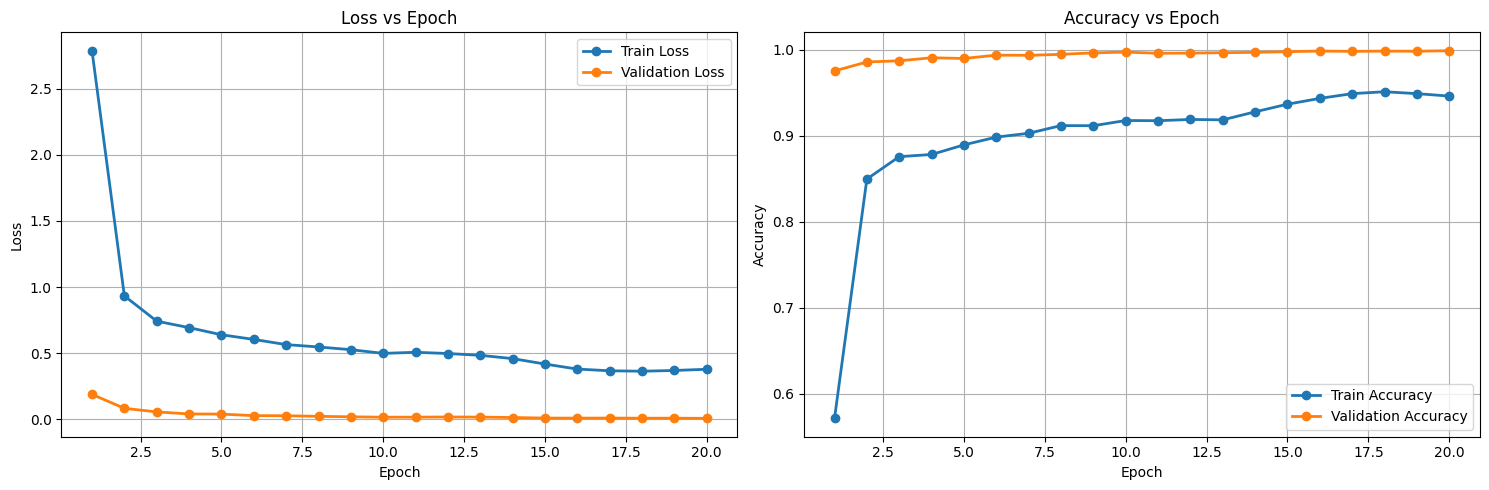

In [115]:
model = multimodal_model

model, history, best_val_acc = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    scaler=scaler,

    device=device,

    initial_epochs=20,

    patience=10

)

In [116]:
print(train_dataset.__dict__.keys())

dict_keys(['fp_dict', 'iris_dict', 'voice_dict', 'fp_root', 'iris_root', 'voice_root', 'fp_transform', 'iris_transform', 'voice_transform', 'samples_per_identity', 'deterministic', 'identities'])


In [117]:
print(type(train_dataset.fp_dict))

first_key = list(train_dataset.fp_dict.keys())[0]

print(first_key)

print(train_dataset.fp_dict[first_key][0])

<class 'dict'>
0
{'modality_type': 'fingerprint', 'image_path': '/kaggle/input/datasets/ruizgara/socofing/SOCOFing/Altered/Altered-Medium/1__M_Left_little_finger_Zcut.BMP', 'multimodal_id': 0, 'person_id': 1, 'finger': 'M_Left_little', 'difficulty': 'medium', 'alteration': 'finger', 'finger_identity': '1_M_Left_little', 'finger_id': 331, 'split': 'train'}


In [118]:
weights.mean(dim=0)

tensor([0.3289, 0.3468, 0.3242], device='cuda:0')

In [119]:
weights.std(dim=0)

tensor([nan, nan, nan], device='cuda:0')

In [120]:
import torch
import numpy as np
from tqdm.auto import tqdm


@torch.no_grad()
def test_model(
        model,
        test_loader,
        criterion,
        device
):

    model.eval()

    running_loss = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    all_embeddings = []
    all_weights = []

    pbar = tqdm(test_loader)

    for batch in pbar:

        fingerprint = batch["fingerprint"].to(device)
        iris = batch["iris"].to(device)
        voice = batch["voice"].to(device)
        labels = batch["label"].to(device)

        with torch.amp.autocast("cuda"):

            outputs = model(

                fingerprint,

                iris,

                voice

            )

            logits = outputs["logits"]

            loss = criterion(

                logits,

                labels

            )

        probs = torch.softmax(

            logits,

            dim=1

        )

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * labels.size(0)

        total += labels.size(0)

        ####################################################

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

        all_embeddings.append(

            outputs["fused_embedding"].cpu()

        )

        all_weights.append(

            outputs["weights"].cpu()

        )

    ########################################################

    test_loss = running_loss / total

    all_embeddings = torch.cat(

        all_embeddings,

        dim=0

    )

    all_weights = torch.cat(

        all_weights,

        dim=0

    )

    return (

        test_loss,

        np.array(all_labels),

        np.array(all_preds),

        np.array(all_probs),

        all_embeddings,

        all_weights

    )

In [121]:
from sklearn.metrics import (
    accuracy_score,
    top_k_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt


def evaluate_metrics(

        test_loss,

        all_labels,

        all_preds,

        all_probs

):

    ########################################################

    accuracy = accuracy_score(

        all_labels,

        all_preds

    )

    ########################################################

    top3_acc = top_k_accuracy_score(

        all_labels,

        all_probs,

        k=3

    )

    ########################################################

    top5_acc = top_k_accuracy_score(

        all_labels,

        all_probs,

        k=5

    )

    ########################################################

    precision = precision_score(

        all_labels,

        all_preds,

        average="weighted"

    )

    ########################################################

    recall = recall_score(

        all_labels,

        all_preds,

        average="weighted"

    )

    ########################################################

    f1 = f1_score(

        all_labels,

        all_preds,

        average="weighted"

    )

    ########################################################

    cm = confusion_matrix(

        all_labels,

        all_preds

    )

    ########################################################

    report = classification_report(

        all_labels,

        all_preds

    )

    ########################################################

    print("="*60)

    print(f"Test Loss      : {test_loss:.4f}")

    print(f"Top-1 Accuracy : {accuracy:.4f}")

    print(f"Top-3 Accuracy : {top3_acc:.4f}")

    print(f"Top-5 Accuracy : {top5_acc:.4f}")

    print(f"Precision      : {precision:.4f}")

    print(f"Recall         : {recall:.4f}")

    print(f"F1 Score       : {f1:.4f}")

    print("="*60)

    print("\nClassification Report\n")

    print(report)

    ########################################################

    plt.figure(figsize=(12,10))

    sns.heatmap(

        cm,

        cmap="Blues"

    )

    plt.title("Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.show()

    ########################################################

    results = {

        "test_loss": test_loss,

        "accuracy": accuracy,

        "top3_accuracy": top3_acc,

        "top5_accuracy": top5_acc,

        "precision": precision,

        "recall": recall,

        "f1_score": f1,

        "confusion_matrix": cm,

        "classification_report": report

    }

    return results

In [128]:
class NaiveFusionModel(nn.Module):
    """
    Baseline: fixed equal-weight (1/3, 1/3, 1/3) fusion.
    No gate, no embedding-summary network. Everything else
    (experts, projections, modality dropout, placeholders,
    fusion MLP, classifier) is identical to the adaptive model
    so the comparison isolates the effect of the gate.
    """

    def __init__(
        self,
        fp_expert, iris_expert, voice_expert,
        fp_projection, iris_projection, voice_projection,
        fusion_module,
        classifier,
        num_classes=204,
        modality_dropout_p=0.15
    ):
        super().__init__()

        self.fp_expert = fp_expert
        self.iris_expert = iris_expert
        self.voice_expert = voice_expert

        self.fp_projection = fp_projection
        self.iris_projection = iris_projection
        self.voice_projection = voice_projection

        self.fusion_module = fusion_module
        self.classifier = classifier

        self.modality_dropout_p = modality_dropout_p
        self.num_classes = num_classes

        # Same placeholder mechanism as the adaptive model,
        # so missing-modality handling is fair between both.
        self.fp_placeholder = nn.Parameter(torch.randn(1, 512) * 0.01)
        self.iris_placeholder = nn.Parameter(torch.randn(1, 512) * 0.01)
        self.voice_placeholder = nn.Parameter(torch.randn(1, 512) * 0.01)

    def forward(self, fingerprint, iris, voice, force_drop=None):

        fp_out = self.fp_expert(fingerprint)
        iris_out = self.iris_expert(iris)
        voice_out = self.voice_expert(voice)

        fp_proj = self.fp_projection(fp_out["embedding"])
        iris_proj = self.iris_projection(iris_out["embedding"])
        voice_proj = self.voice_projection(voice_out["embedding"])

        batch_size = fingerprint.size(0)
        device = fingerprint.device

        # ---------------- modality dropout (identical logic to adaptive model) ----------------
        if self.training and self.modality_dropout_p > 0:
            device = fingerprint.device
        
            # ============================================
            # Structured curriculum sampling: instead of
            # independent per-modality Bernoulli dropout
            # (which starves rare "exactly one modality
            # survives" cases to ~1.9% of batches), sample
            # an explicit scenario per training sample from
            # a fixed distribution that guarantees adequate
            # exposure to every combination.
            # ============================================
            scenario_names = [
                "all_present",
                "fp_missing", "iris_missing", "voice_missing",
                "voice_only",   # fp + iris missing
                "iris_only",    # fp + voice missing
                "fp_only",      # iris + voice missing
            ]
        
            # Tune these based on how much rare-case exposure you want.
            # All-present still dominates (real-world common case), but
            # single-survivor cases now get a guaranteed, fixed share
            # instead of ~1.9% each under independent dropout.
            scenario_probs = torch.tensor([
                0.40,   # all_present
                0.10, 0.10, 0.10,   # each single-missing
                0.10, 0.10, 0.10,   # each single-survivor (double-missing)
            ], device=device)
        
            scenario_idx = torch.multinomial(
                scenario_probs, batch_size, replacement=True
            )
        
            fp_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
            iris_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
            voice_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
        
            fp_drop[(scenario_idx == 1) | (scenario_idx == 4) | (scenario_idx == 5)] = True
            iris_drop[(scenario_idx == 2) | (scenario_idx == 4) | (scenario_idx == 6)] = True
            voice_drop[(scenario_idx == 3) | (scenario_idx == 5) | (scenario_idx == 6)] = True

        elif force_drop is not None:
            fp_drop = torch.full((batch_size, 1), "fp" in force_drop, device=device)
            iris_drop = torch.full((batch_size, 1), "iris" in force_drop, device=device)
            voice_drop = torch.full((batch_size, 1), "voice" in force_drop, device=device)

        else:
            fp_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
            iris_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)
            voice_drop = torch.zeros(batch_size, 1, dtype=torch.bool, device=device)

        fp_proj = torch.where(fp_drop, self.fp_placeholder.expand(batch_size, -1), fp_proj)
        iris_proj = torch.where(iris_drop, self.iris_placeholder.expand(batch_size, -1), iris_proj)
        voice_proj = torch.where(voice_drop, self.voice_placeholder.expand(batch_size, -1), voice_proj)

        # ---------------- FIXED equal weights, no gate ----------------
        weights = torch.full((batch_size, 3), 1.0 / 3.0, device=device)

        fused_embedding = self.fusion_module(fp_proj, iris_proj, voice_proj, weights)
        logits = self.classifier(fused_embedding)

        return {
            "logits": logits,
            "fused_embedding": fused_embedding,
            "weights": weights,
        }

In [132]:
def evaluate_degradation2(model, test_loader, criterion, device, conditions):
    results = {}
    model.eval()

    for name, drop_list in conditions.items():
        running_loss = 0
        total = 0
        all_labels, all_preds, all_probs, all_embeddings = [], [], [], []
        with torch.no_grad():
            for batch in test_loader:
                fingerprint = batch["fingerprint"].to(device)
                iris = batch["iris"].to(device)
                voice = batch["voice"].to(device)
                labels = batch["label"].to(device)
                with torch.amp.autocast("cuda"):
                    outputs = model(fingerprint, iris, voice, force_drop=drop_list)
                    logits = outputs["logits"]
                    loss = criterion(logits, labels)
                probs = torch.softmax(logits, dim=1)
                preds = logits.argmax(dim=1)
                running_loss += loss.item() * labels.size(0)
                total += labels.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_embeddings.append(outputs["fused_embedding"].cpu())
        test_loss = running_loss / total
        all_embeddings = torch.cat(all_embeddings, dim=0)
        verif = compute_eer_and_curves(all_embeddings, np.array(all_labels))
        print(f"\n{'='*80}\nCondition: {name}\n{'='*80}")
        results[name] = evaluate_metrics(
        test_loss,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )
    
        results[name]["eer"] = verif["eer"]
        results[name]["raw_preds"] = np.array(all_preds)
        results[name]["raw_labels"] = np.array(all_labels)
    return results


degradation_conditions = {
    "All present":         None,
    "Fingerprint missing": ["fp"],
    "Iris missing":        ["iris"],
    "Voice missing":       ["voice"],
    "FP + Iris missing":   ["fp", "iris"],
    "FP + Voice missing":  ["fp", "voice"],
    "Iris + Voice missing":["iris", "voice"],
}



STARTING SEEDED RUN: seed=101

--- Training ADAPTIVE model (seed=101) ---


Training Model:   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/408 [00:00<?, ?it/s]

Epoch [1]
Val Loss   : 0.1821
Val Acc    : 0.9816  (degradation-averaged)
    all_present    : 1.0000
    fp_missing     : 0.9960
    iris_missing   : 0.9323
    voice_missing  : 0.9982

Train Loss : 2.8000
Train Acc  : 0.5663
Val Acc    : 0.9816
Learning Rate : 1.00e-03

Best Model Saved (Validation Accuracy = 0.9816)


  0%|          | 0/408 [00:00<?, ?it/s]

...

Epoch [19]
Val Loss   : 0.0039
Val Acc    : 0.9992  (degradation-averaged)
    all_present    : 1.0000
    fp_missing     : 1.0000
    iris_missing   : 0.9969
    voice_missing  : 1.0000

Train Loss : 0.3661
Train Acc  : 0.9476
Val Acc    : 0.9992
Learning Rate : 5.00e-04

Best Model Saved (Validation Accuracy = 0.9992)


  0%|          | 0/408 [00:00<?, ?it/s]

Epoch [20]
Val Loss   : 0.0057
Val Acc    : 0.9985  (degradation-averaged)
    all_present    : 1.0000
    fp_missing     : 1.0000
    iris_missing   : 0.9951
    voice_missing  : 0.9991

Train Loss : 0.3612
Train Acc  : 0.9485
Val Acc    : 0.9985
Learning Rate : 5.00e-04



Continue training? (y/n):  n



Training Finished.


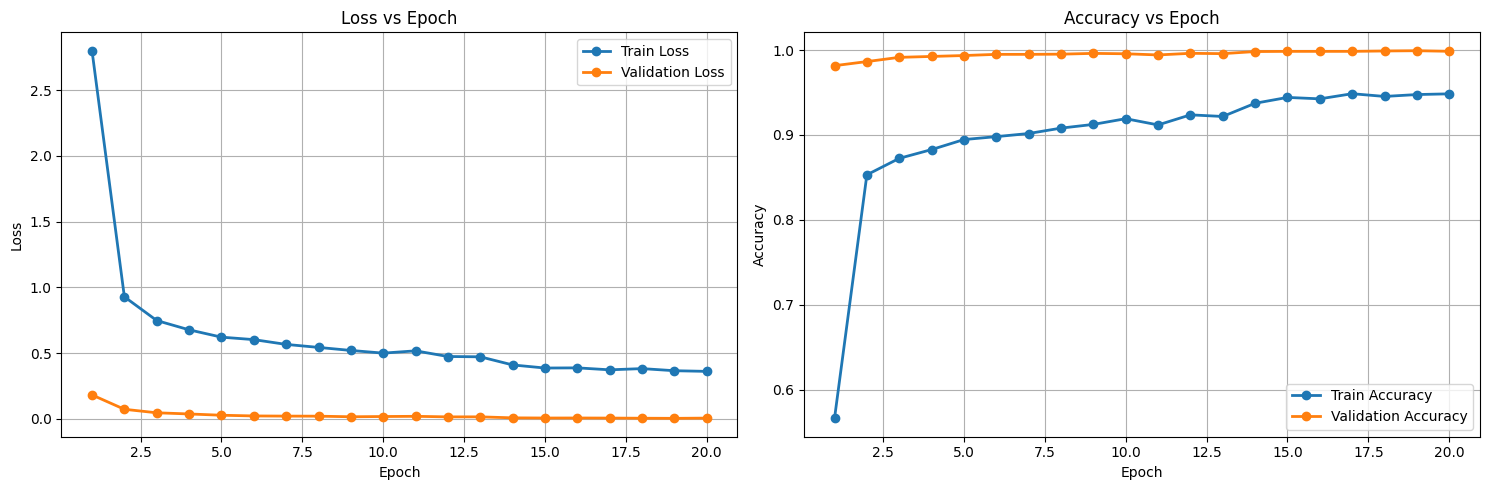

Adaptive checkpoint saved: best_adaptive_model_seed101.pth

--- Training NAIVE model (seed=101) ---


Training Model:   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/408 [00:00<?, ?it/s]

Epoch [1]
Val Loss   : 0.1819
Val Acc    : 0.9780  (degradation-averaged)
    all_present    : 0.9994
    fp_missing     : 0.9979
    iris_missing   : 0.9216
    voice_missing  : 0.9933

Train Loss : 2.5662
Train Acc  : 0.5666
Val Acc    : 0.9780
Learning Rate : 1.00e-03

Best Model Saved (Validation Accuracy = 0.9780)


  0%|          | 0/408 [00:00<?, ?it/s]

...

Epoch [19]
Val Loss   : 0.0060
Val Acc    : 0.9982  (degradation-averaged)
    all_present    : 1.0000
    fp_missing     : 1.0000
    iris_missing   : 0.9939
    voice_missing  : 0.9991

Train Loss : 0.1759
Train Acc  : 0.9516
Val Acc    : 0.9982
Learning Rate : 5.00e-04

Best Model Saved (Validation Accuracy = 0.9982)


  0%|          | 0/408 [00:00<?, ?it/s]

Epoch [20]
Val Loss   : 0.0044
Val Acc    : 0.9991  (degradation-averaged)
    all_present    : 1.0000
    fp_missing     : 1.0000
    iris_missing   : 0.9963
    voice_missing  : 1.0000

Train Loss : 0.1661
Train Acc  : 0.9531
Val Acc    : 0.9991
Learning Rate : 5.00e-04

Best Model Saved (Validation Accuracy = 0.9991)



Continue training? (y/n):  n



Training Finished.


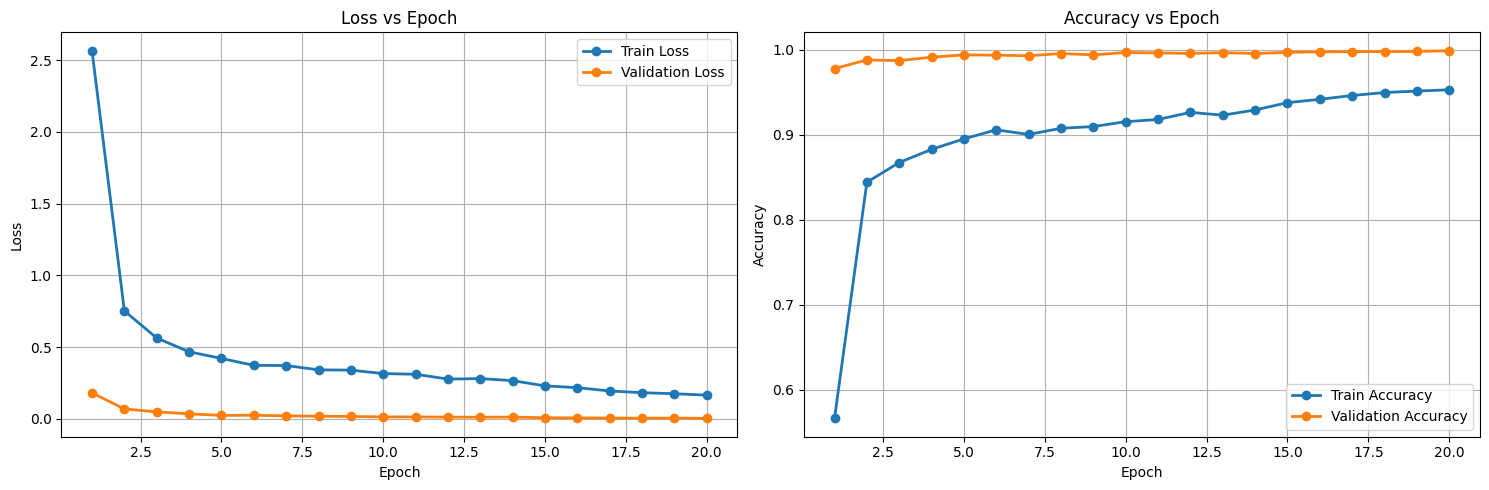

Naive checkpoint saved: best_naive_model_seed101.pth

--- Evaluating ADAPTIVE model (seed=101) ---

Condition: All present
Test Loss      : 0.0001
Top-1 Accuracy : 1.0000
Top-3 Accuracy : 1.0000
Top-5 Accuracy : 1.0000
Precision      : 1.0000
Recall         : 1.0000
F1 Score       : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       1.00      1.00   

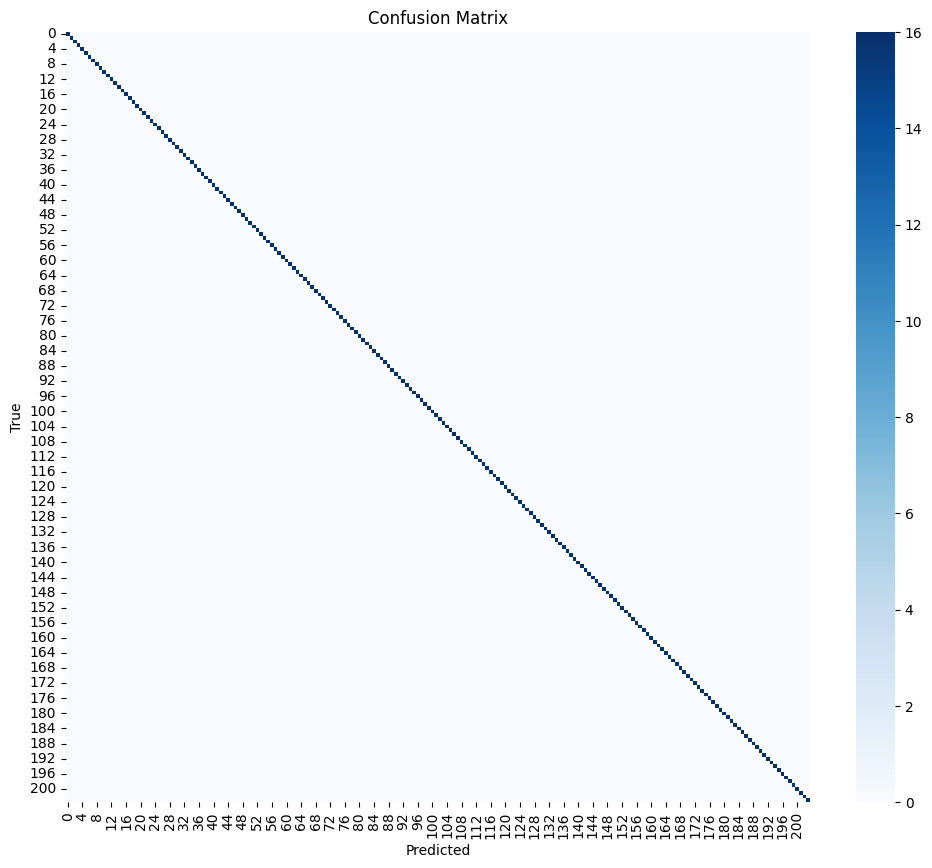


Condition: Fingerprint missing
Test Loss      : 0.0033
Top-1 Accuracy : 0.9994
Top-3 Accuracy : 1.0000
Top-5 Accuracy : 1.0000
Precision      : 0.9994
Recall         : 0.9994
F1 Score       : 0.9994

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        16
          13       

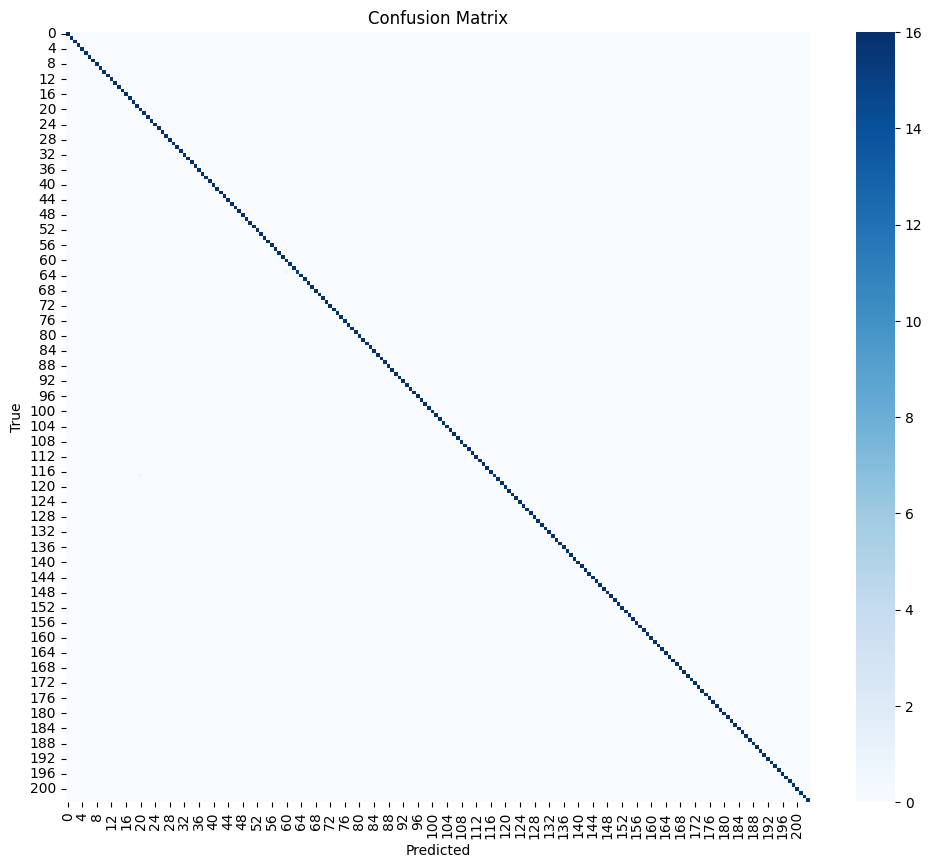


Condition: Iris missing
Test Loss      : 0.0208
Top-1 Accuracy : 0.9948
Top-3 Accuracy : 0.9985
Top-5 Accuracy : 0.9994
Precision      : 0.9951
Recall         : 0.9948
F1 Score       : 0.9948

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        16
          13       1.00   

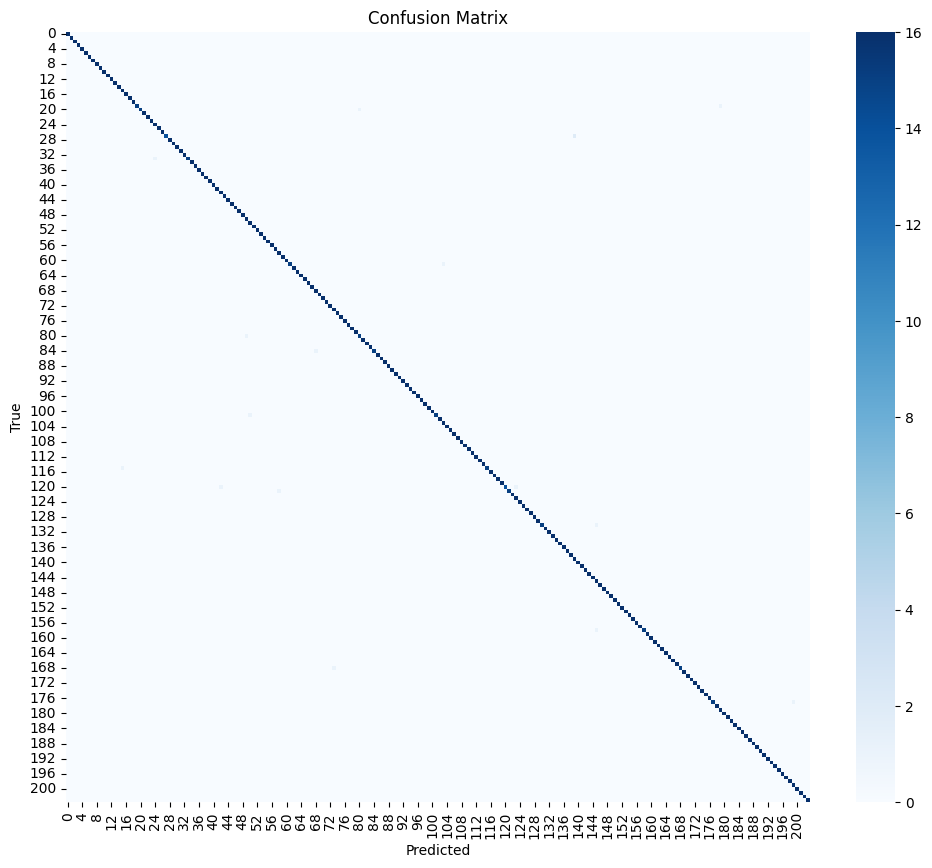


Condition: Voice missing
Test Loss      : 0.0035
Top-1 Accuracy : 0.9982
Top-3 Accuracy : 0.9997
Top-5 Accuracy : 1.0000
Precision      : 0.9983
Recall         : 0.9982
F1 Score       : 0.9981

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        16
          13       1.00  

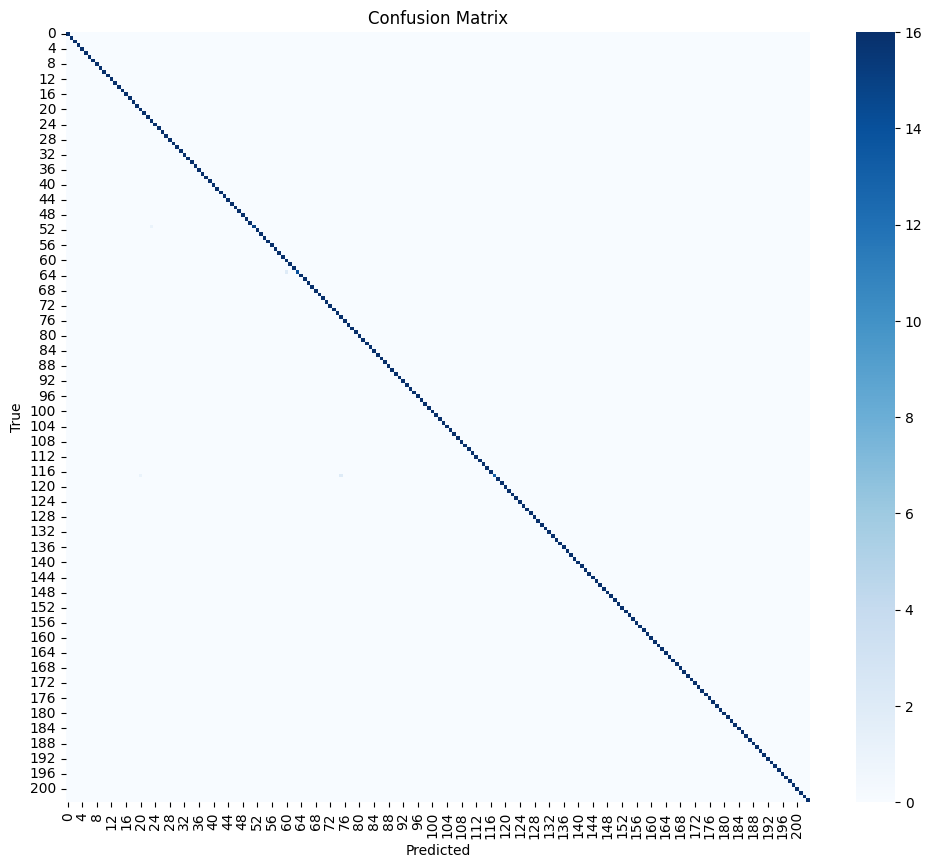


Condition: FP + Iris missing
Test Loss      : 0.6315
Top-1 Accuracy : 0.8741
Top-3 Accuracy : 0.9393
Top-5 Accuracy : 0.9553
Precision      : 0.8868
Recall         : 0.8741
F1 Score       : 0.8741

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.88      0.90        16
           1       0.81      0.81      0.81        16
           2       0.84      1.00      0.91        16
           3       0.73      1.00      0.84        16
           4       1.00      0.94      0.97        16
           5       0.79      0.94      0.86        16
           6       1.00      0.69      0.81        16
           7       0.70      0.88      0.78        16
           8       0.82      0.88      0.85        16
           9       0.88      0.44      0.58        16
          10       0.76      1.00      0.86        16
          11       1.00      1.00      1.00        16
          12       0.92      0.75      0.83        16
          13       0.

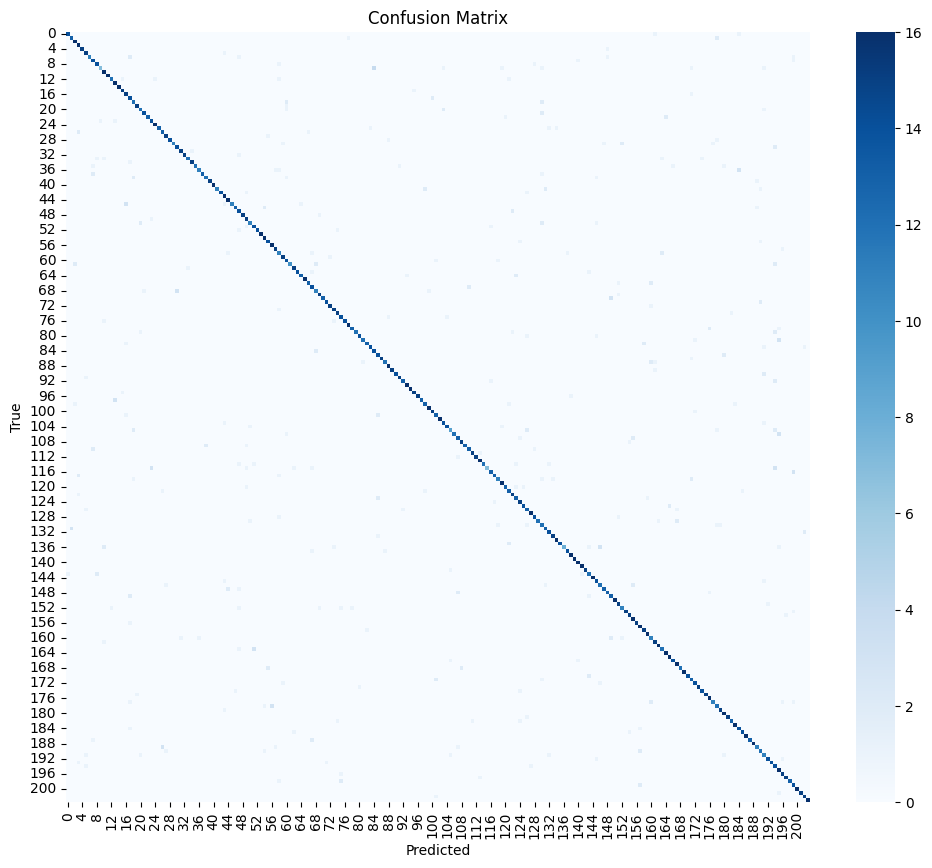


Condition: FP + Voice missing
Test Loss      : 0.0528
Top-1 Accuracy : 0.9933
Top-3 Accuracy : 0.9982
Top-5 Accuracy : 0.9982
Precision      : 0.9954
Recall         : 0.9933
F1 Score       : 0.9929

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        16
          13       1

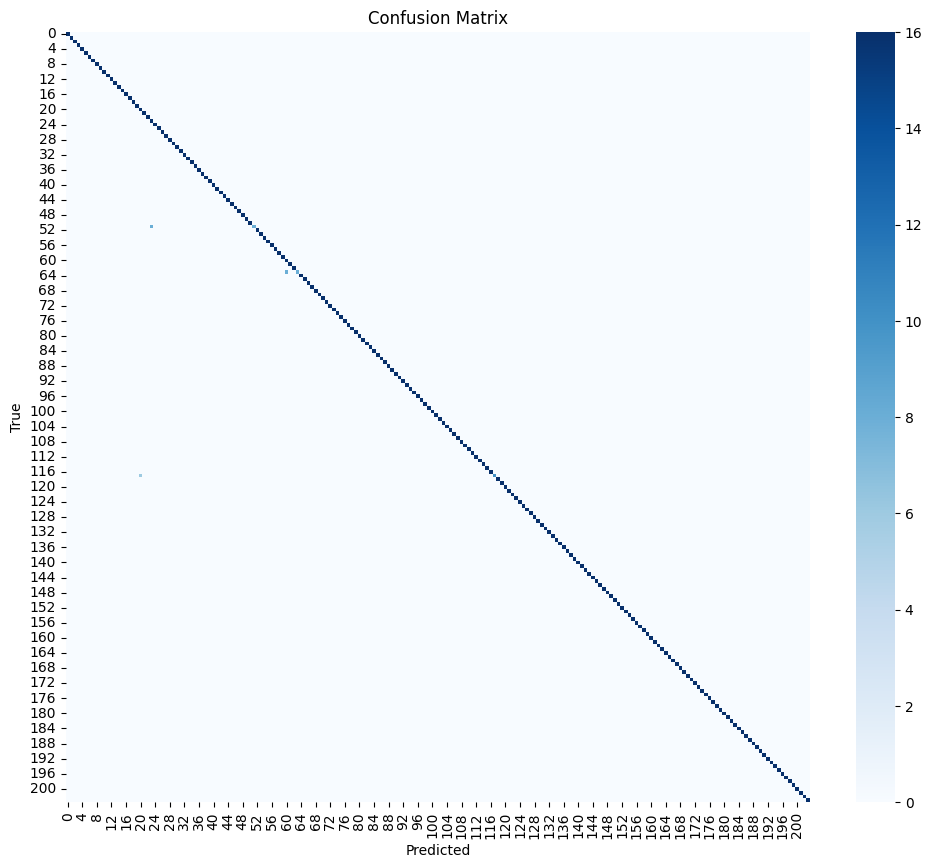


Condition: Iris + Voice missing
Test Loss      : 0.3306
Top-1 Accuracy : 0.9013
Top-3 Accuracy : 0.9715
Top-5 Accuracy : 0.9847
Precision      : 0.9161
Recall         : 0.9013
F1 Score       : 0.8975

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.94      1.00      0.97        16
           2       0.94      1.00      0.97        16
           3       0.94      1.00      0.97        16
           4       1.00      1.00      1.00        16
           5       1.00      0.94      0.97        16
           6       0.94      1.00      0.97        16
           7       1.00      0.94      0.97        16
           8       1.00      1.00      1.00        16
           9       0.80      1.00      0.89        16
          10       0.94      1.00      0.97        16
          11       1.00      0.81      0.90        16
          12       0.89      1.00      0.94        16
          13      

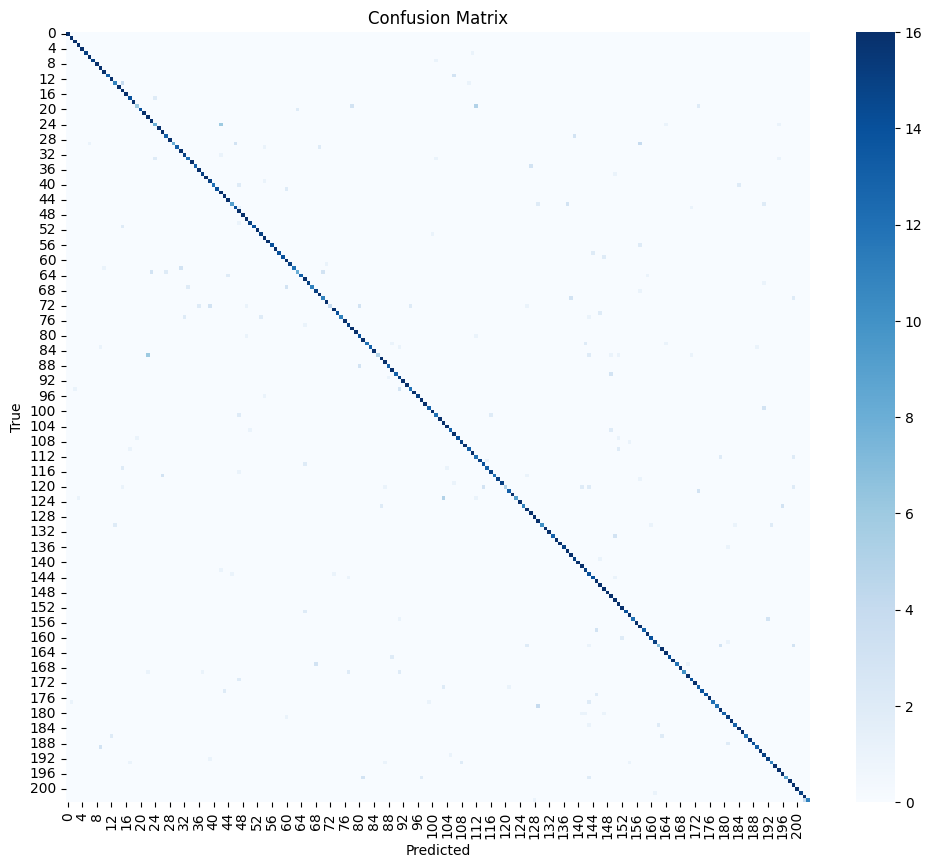


--- Evaluating NAIVE model (seed=101) ---

Condition: All present
Test Loss      : 0.0000
Top-1 Accuracy : 1.0000
Top-3 Accuracy : 1.0000
Top-5 Accuracy : 1.0000
Precision      : 1.0000
Recall         : 1.0000
F1 Score       : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       1.00      1.00      1.00        16
          12       1.00      1.00     

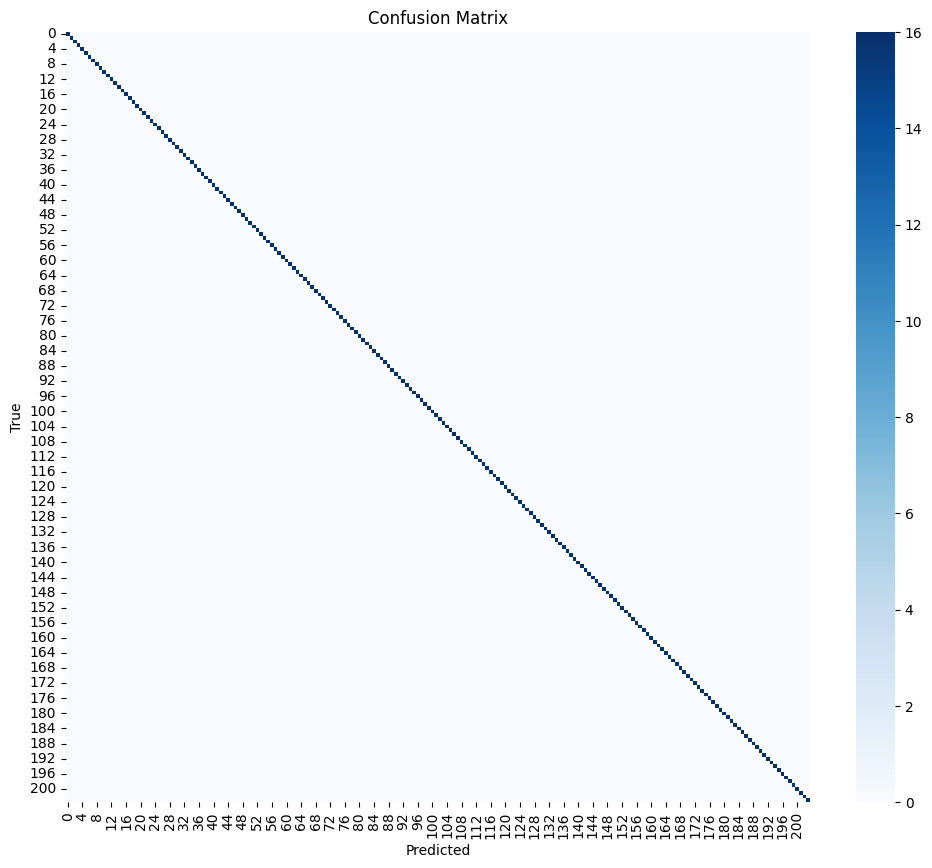


Condition: Fingerprint missing
Test Loss      : 0.0019
Top-1 Accuracy : 0.9997
Top-3 Accuracy : 1.0000
Top-5 Accuracy : 1.0000
Precision      : 0.9997
Recall         : 0.9997
F1 Score       : 0.9997

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        16
          13       

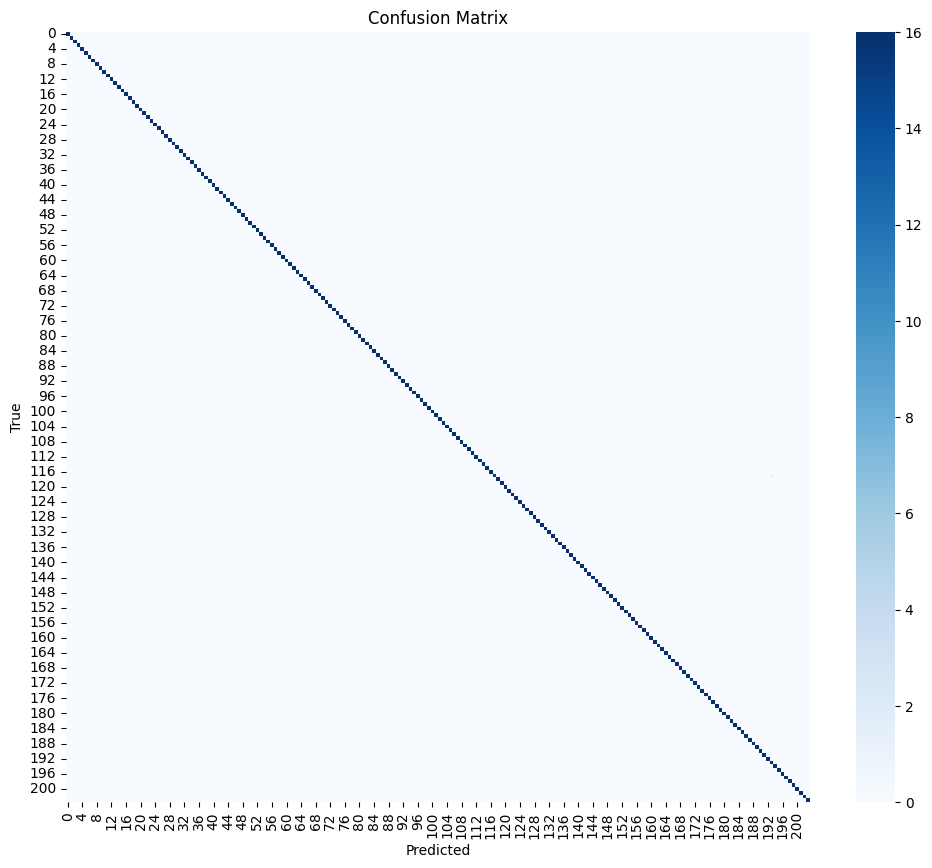


Condition: Iris missing
Test Loss      : 0.0279
Top-1 Accuracy : 0.9908
Top-3 Accuracy : 0.9985
Top-5 Accuracy : 0.9994
Precision      : 0.9916
Recall         : 0.9908
F1 Score       : 0.9908

Classification Report

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       0.84      1.00      0.91        16
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        16
           4       1.00      0.94      0.97        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        16
           9       1.00      0.88      0.93        16
          10       1.00      1.00      1.00        16
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        16
          13       1.00   

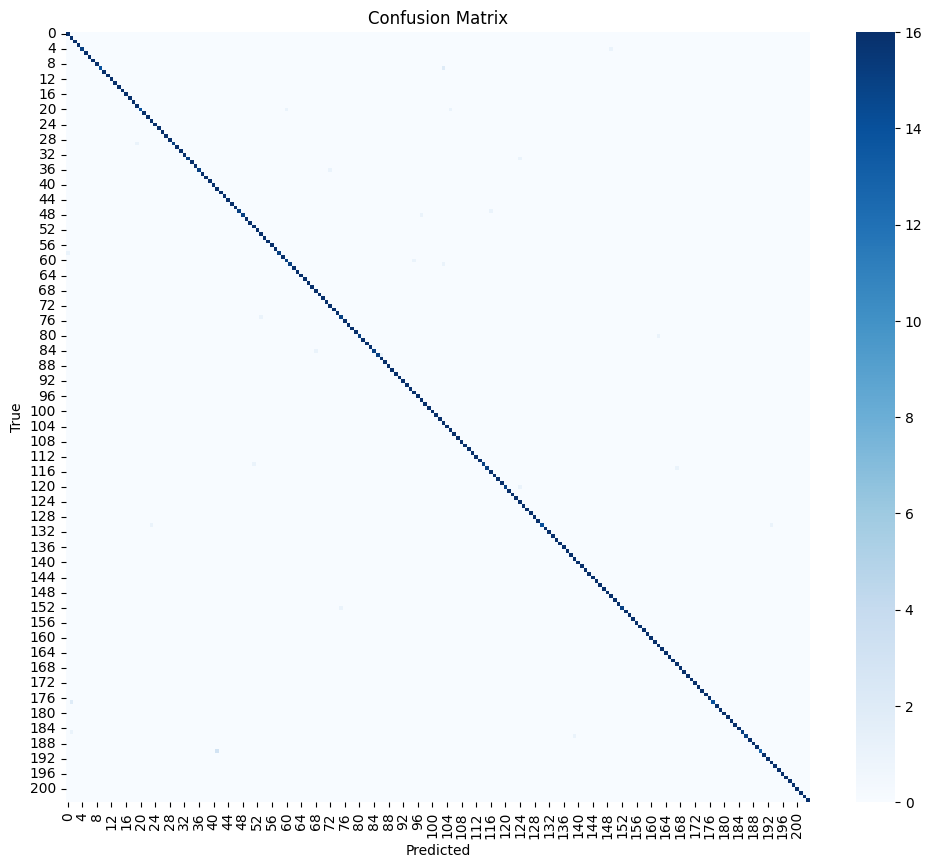


Condition: Voice missing
Test Loss      : 0.0017
Top-1 Accuracy : 0.9991
Top-3 Accuracy : 1.0000
Top-5 Accuracy : 1.0000
Precision      : 0.9991
Recall         : 0.9991
F1 Score       : 0.9991

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        16
          13       1.00  

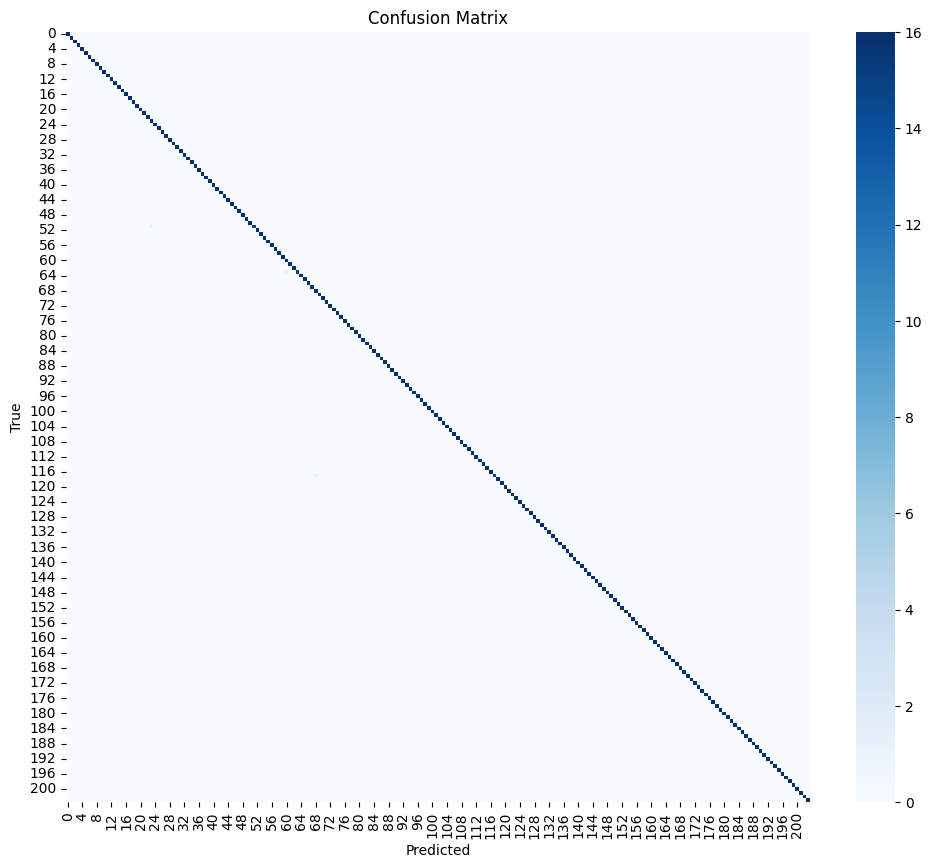


Condition: FP + Iris missing
Test Loss      : 0.5722
Top-1 Accuracy : 0.8606
Top-3 Accuracy : 0.9375
Top-5 Accuracy : 0.9580
Precision      : 0.8726
Recall         : 0.8606
F1 Score       : 0.8597

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        16
           1       0.74      0.88      0.80        16
           2       0.94      1.00      0.97        16
           3       1.00      1.00      1.00        16
           4       0.88      0.94      0.91        16
           5       0.73      1.00      0.84        16
           6       1.00      0.81      0.90        16
           7       0.70      0.88      0.78        16
           8       0.81      0.81      0.81        16
           9       0.82      0.56      0.67        16
          10       0.76      1.00      0.86        16
          11       1.00      1.00      1.00        16
          12       0.65      0.81      0.72        16
          13       0.

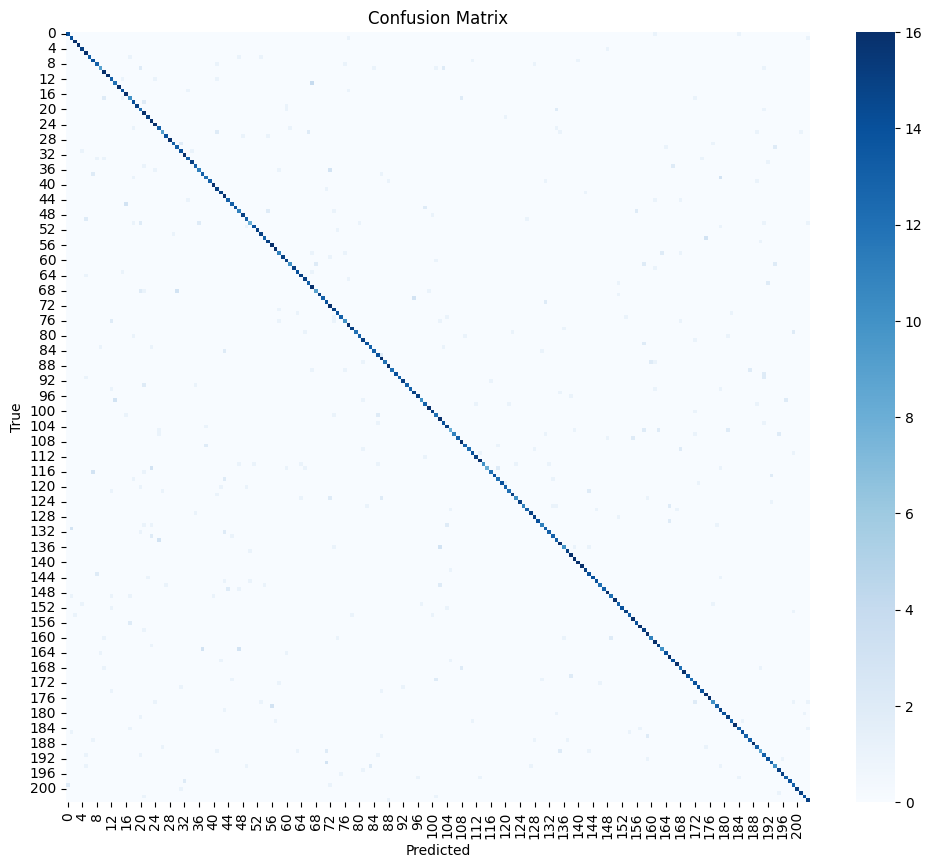


Condition: FP + Voice missing
Test Loss      : 0.0363
Top-1 Accuracy : 0.9933
Top-3 Accuracy : 0.9957
Top-5 Accuracy : 0.9982
Precision      : 0.9954
Recall         : 0.9933
F1 Score       : 0.9929

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        16
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        16
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        16
          13       1

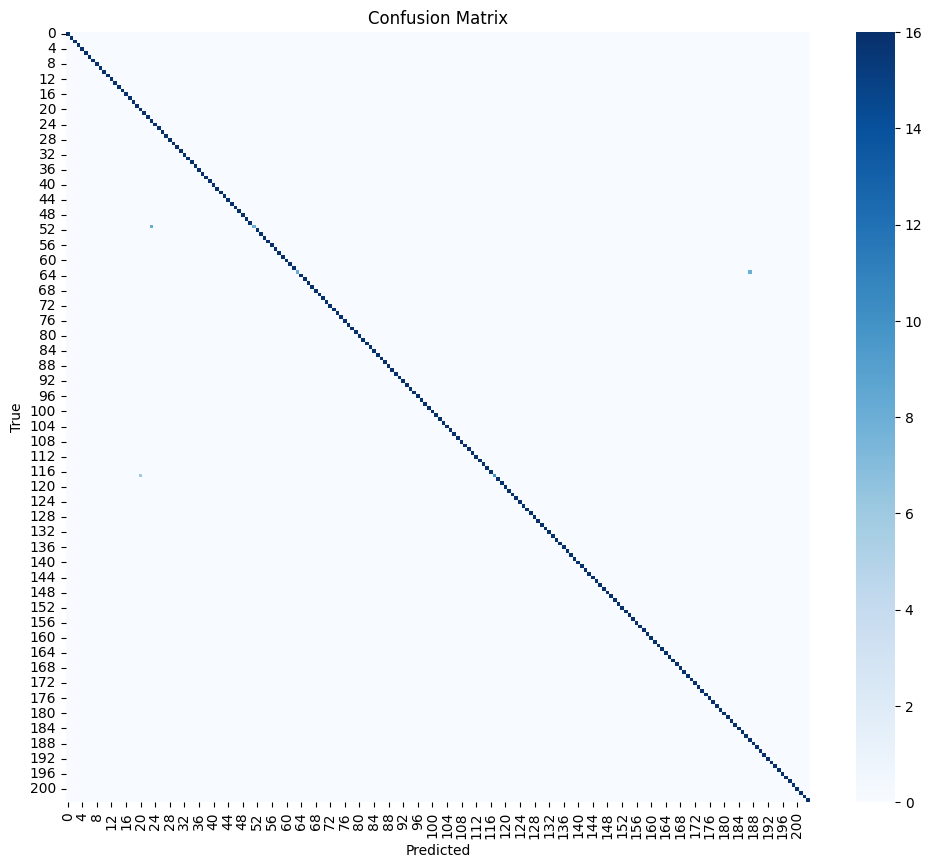


Condition: Iris + Voice missing
Test Loss      : 0.4043
Top-1 Accuracy : 0.8854
Top-3 Accuracy : 0.9681
Top-5 Accuracy : 0.9841
Precision      : 0.9076
Recall         : 0.8854
F1 Score       : 0.8847

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.84      1.00      0.91        16
           2       0.94      1.00      0.97        16
           3       1.00      0.75      0.86        16
           4       0.70      0.88      0.78        16
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        16
           7       0.80      1.00      0.89        16
           8       0.89      1.00      0.94        16
           9       1.00      1.00      1.00        16
          10       0.57      1.00      0.73        16
          11       0.80      0.75      0.77        16
          12       1.00      0.69      0.81        16
          13      

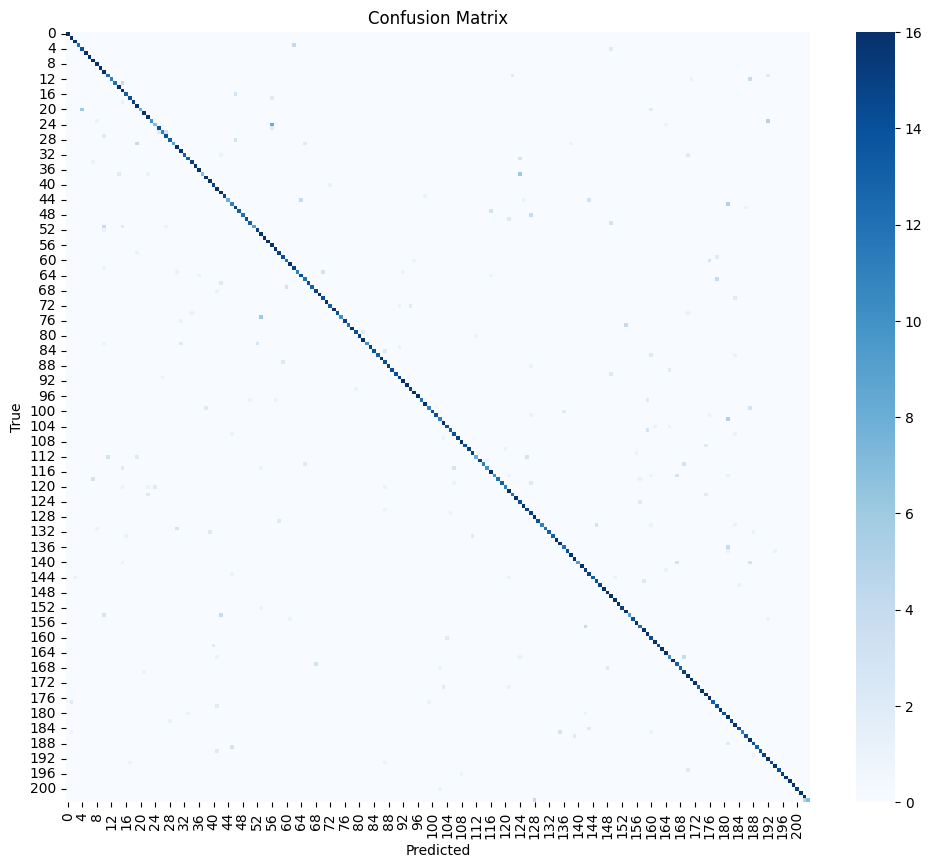


Raw predictions saved: raw_predictions_seed101.pkl

Condition                     Adaptive        Naive          Δ   (seed=101)
----------------------------------------------------------------------
All present                     1.0000       1.0000    +0.0000
Fingerprint missing             0.9994       0.9997    -0.0003
Iris missing                    0.9948       0.9908    +0.0040
Voice missing                   0.9982       0.9991    -0.0009
FP + Iris missing               0.8741       0.8606    +0.0135
FP + Voice missing              0.9933       0.9933    +0.0000
Iris + Voice missing            0.9013       0.8854    +0.0159

SEEDED RUN COMPLETE: seed=101


In [141]:
# ============================================================
# SEEDED REPRODUCIBILITY RUN
# Change SEED below, then run this cell top-to-bottom.
# Everything else in the notebook (frozen experts, temperature
# values, test_loader, degradation_conditions) is reused as-is.
# ============================================================

SEED = 101   # <-- change this each run: 101, 202, 303, ...

import torch
import numpy as np
import random
import pickle

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"{'='*80}\nSTARTING SEEDED RUN: seed={SEED}\n{'='*80}")

# ------------------------------------------------------------
# 1. Build the ADAPTIVE model fresh
# ------------------------------------------------------------
fp_projection = ProjectionHead().to(device)
iris_projection = ProjectionHead().to(device)
voice_projection = ProjectionHead().to(device)
fp_summary = EmbeddingSummary().to(device)
iris_summary = EmbeddingSummary().to(device)
voice_summary = EmbeddingSummary().to(device)
adaptive_gate = AdaptiveConfidenceGate().to(device)
fusion_module = AdaptiveFusion().to(device)
classifier = MultimodalClassifier().to(device)

model = MultimodalBiometricModel(
    fp_expert, iris_expert, voice_expert,
    fp_projection, iris_projection, voice_projection,
    fp_summary, iris_summary, voice_summary,
    adaptive_gate, fusion_module, classifier,
    modality_dropout_p=0.15
).to(device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)
scaler = torch.amp.GradScaler("cuda")

print(f"\n--- Training ADAPTIVE model (seed={SEED}) ---")
model, history, best_val_acc = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, scaler, device,
    initial_epochs=20, patience=15
)

import shutil
shutil.copy("best_multimodal_model.pth", f"best_adaptive_model_seed{SEED}.pth")
print(f"Adaptive checkpoint saved: best_adaptive_model_seed{SEED}.pth")

# ------------------------------------------------------------
# 2. Build the NAIVE baseline fresh (independent projections)
# ------------------------------------------------------------
fp_projection_baseline = ProjectionHead().to(device)
iris_projection_baseline = ProjectionHead().to(device)
voice_projection_baseline = ProjectionHead().to(device)
fusion_module_baseline = AdaptiveFusion().to(device)
classifier_baseline = MultimodalClassifier().to(device)

naive_model = NaiveFusionModel(
    fp_expert, iris_expert, voice_expert,
    fp_projection_baseline, iris_projection_baseline, voice_projection_baseline,
    fusion_module_baseline, classifier_baseline,
    modality_dropout_p=0.15
).to(device)

naive_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, naive_model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
naive_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    naive_optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)
naive_scaler = torch.amp.GradScaler("cuda")

print(f"\n--- Training NAIVE model (seed={SEED}) ---")
naive_model, naive_history, naive_best_val_acc = train_model(
    naive_model, train_loader, val_loader, criterion, naive_optimizer, naive_scheduler, naive_scaler, device,
    initial_epochs=20, patience=15
)

shutil.copy("best_multimodal_model.pth", f"best_naive_model_seed{SEED}.pth")
print(f"Naive checkpoint saved: best_naive_model_seed{SEED}.pth")

# ------------------------------------------------------------
# 3. Evaluate both models across all degradation conditions
# ------------------------------------------------------------
print(f"\n--- Evaluating ADAPTIVE model (seed={SEED}) ---")
adaptive_results = evaluate_degradation2(model, test_loader, criterion, device, degradation_conditions)

print(f"\n--- Evaluating NAIVE model (seed={SEED}) ---")
naive_results = evaluate_degradation2(naive_model, test_loader, criterion, device, degradation_conditions)

# ------------------------------------------------------------
# 4. Save raw predictions for pooled McNemar testing later
# ------------------------------------------------------------
pooled_data = {
    "seed": SEED,
    "adaptive": {cond: {"preds": adaptive_results[cond]["raw_preds"],
                        "labels": adaptive_results[cond]["raw_labels"]}
                 for cond in degradation_conditions},
    "naive": {cond: {"preds": naive_results[cond]["raw_preds"],
                      "labels": naive_results[cond]["raw_labels"]}
              for cond in degradation_conditions},
}

with open(f"raw_predictions_seed{SEED}.pkl", "wb") as f:
    pickle.dump(pooled_data, f)
print(f"\nRaw predictions saved: raw_predictions_seed{SEED}.pkl")

# ------------------------------------------------------------
# 5. Print this run's summary comparison table
# ------------------------------------------------------------
print(f"\n{'Condition':25s} {'Adaptive':>12s} {'Naive':>12s} {'Δ':>10s}   (seed={SEED})")
print("-" * 70)
for cond in degradation_conditions:
    a = adaptive_results[cond]["accuracy"]
    n = naive_results[cond]["accuracy"]
    print(f"{cond:25s} {a:12.4f} {n:12.4f} {a-n:+10.4f}")

print(f"\n{'='*80}\nSEEDED RUN COMPLETE: seed={SEED}\n{'='*80}")